In [ ]:
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Data Preprocessing

In [ ]:
import pandas as pd
import json

project_dir = '/content/drive/MyDrive/VisualReview'

print("Loading reviews...")
reviews = []
with open(f'{project_dir}/Appliances.jsonl/Appliances.jsonl') as f:
    for line in f:
        reviews.append(json.loads(line))
reviews_df = pd.DataFrame(reviews)
print(f"Reviews loaded: {len(reviews_df):,}")

print("Loading metadata...")
meta = []
with open(f'{project_dir}/meta_Appliances.jsonl/meta_Appliances.jsonl') as f:
    for line in f:
        meta.append(json.loads(line))
meta_df = pd.DataFrame(meta)
print(f"Meta loaded: {len(meta_df):,}")

Loading reviews...
Reviews loaded: 2,128,605
Loading metadata...
Meta loaded: 94,327


In [ ]:
# Cell 2: Inspect both dataframes
print("=== REVIEWS COLUMNS ===")
print(reviews_df.columns.tolist())
print("\n=== REVIEWS SAMPLE ===")
print(reviews_df.head(2))

print("\n=== META COLUMNS ===")
print(meta_df.columns.tolist())
print("\n=== META SAMPLE ===")
print(meta_df.head(2))

=== REVIEWS COLUMNS ===
['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']

=== REVIEWS SAMPLE ===
   rating              title                                   text images  \
0     5.0         Work great  work great. use a new one every month     []   
1     5.0  excellent product                Little on the thin side     []   

         asin parent_asin                       user_id      timestamp  \
0  B01N0TQ0OH  B01N0TQ0OH  AGKHLEW2SOWHNMFQIJGBECAF7INQ  1519317108692   
1  B07DD2DMXB  B07DD37QPZ  AHWWLSPCJMALVHDDVSUGICL6RUCA  1664746863446   

   helpful_vote  verified_purchase  
0             0               True  
1             0               True  

=== META COLUMNS ===
['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together', 'subtitle', 'author']

=== META SAMPLE ===
          

In [ ]:
# Cell 3 (FIXED): Keep only columns we need
reviews_clean = reviews_df[[
    'parent_asin',
    'rating',
    'text',
]].copy()

meta_clean = meta_df[[
    'parent_asin',
    'title',
    'images',
    'main_category',
]].copy()

print("Reviews shape:", reviews_clean.shape)
print("Meta shape:", meta_clean.shape)

Reviews shape: (2128605, 3)
Meta shape: (94327, 4)


In [ ]:
# Cell 4 (FIXED): Extract image URL — images is a LIST of dicts
def extract_image_url(images):
    try:
        if not images or len(images) == 0:
            return None
        # each item is a dict with thumb, large, hi_res, variant
        # find the MAIN image first, fall back to first available
        for img in images:
            if img.get('variant') == 'MAIN':
                return img.get('hi_res') or img.get('large') or None
        # fallback: just return first image's hi_res or large
        first = images[0]
        return first.get('hi_res') or first.get('large') or None
    except:
        return None

meta_clean = meta_clean.copy()
meta_clean['image_url'] = meta_clean['images'].apply(extract_image_url)

print("Products with valid image URL:", meta_clean['image_url'].notna().sum())
print("Products without image URL:", meta_clean['image_url'].isna().sum())
print("\nSample image URL:", meta_clean['image_url'].dropna().iloc[0])

Products with valid image URL: 94326
Products without image URL: 1

Sample image URL: https://m.media-amazon.com/images/I/61zNIJh6ZCL._SL1500_.jpg


In [ ]:
# Cell 5 (FIXED): Join reviews with metadata
merged_df = reviews_clean.merge(
    meta_clean[['parent_asin', 'image_url', 'title']],
    on='parent_asin',
    how='inner'
)

print("Merged shape:", merged_df.shape)
print("\nSample row:")
print(merged_df.iloc[0])

Merged shape: (2128605, 5)

Sample row:
parent_asin                                           B01N0TQ0OH
rating                                                       5.0
text                       work great. use a new one every month
image_url      https://m.media-amazon.com/images/I/71zqD75W03...
title          Geesta 12-Pack Premium Activated Charcoal Wate...
Name: 0, dtype: object


In [ ]:
# Cell 6 (FIXED): Filter low quality records
print("Before filtering:", f"{len(merged_df):,}")

filtered_df = merged_df[
    merged_df['image_url'].notna() &
    merged_df['text'].notna() &
    (merged_df['text'].str.len() >= 50) &
    (merged_df['text'].str.len() <= 1000) &
    merged_df['rating'].notna()
].copy()

print("After filtering:", f"{len(filtered_df):,}")
print("\nRating distribution:")
print(filtered_df['rating'].value_counts().sort_index())

Before filtering: 2,128,605
After filtering: 1,391,466

Rating distribution:
rating
1.0    201596
2.0     66238
3.0     83407
4.0    144849
5.0    895376
Name: count, dtype: int64


In [ ]:
# Cell 7: Keep products with at least 3 reviews
reviews_per_product = filtered_df.groupby('parent_asin')['rating'].agg(
    count='count',
    unique_ratings=lambda x: x.nunique()
).reset_index()

good_products = reviews_per_product[reviews_per_product['count'] >= 3]['parent_asin']
filtered_df = filtered_df[filtered_df['parent_asin'].isin(good_products)].copy()

print(f"Products with 3+ reviews: {len(good_products):,}")
print(f"Total records remaining: {len(filtered_df):,}")

Products with 3+ reviews: 38,927
Total records remaining: 1,340,320


In [ ]:
# Cell 8: Save
import os
os.makedirs(f'{project_dir}/processed', exist_ok=True)

output_path = f'{project_dir}/processed/Appliances_joined.jsonl'
filtered_df.to_json(output_path, orient='records', lines=True)
print(f"Saved to {output_path}")
print(f"Final dataset: {len(filtered_df):,} review-image pairs")

Saved to /content/drive/MyDrive/VisualReview/processed/Appliances_joined.jsonl
Final dataset: 1,340,320 review-image pairs


# Image download through URLs

In [ ]:
# Cell 1: Check how many unique products we need to download images for
unique_products = filtered_df[['parent_asin', 'image_url']].drop_duplicates(subset='parent_asin')
print(f"Unique products to download images for: {len(unique_products):,}")
print("\nSample URLs:")
print(unique_products['image_url'].head(5).tolist())

Unique products to download images for: 38,927

Sample URLs:
['https://m.media-amazon.com/images/I/61fC-rtcH7L._AC_SL1500_.jpg', 'https://m.media-amazon.com/images/I/614VU14HAdL._AC_SL1200_.jpg', 'https://m.media-amazon.com/images/I/61S2sHE28UL._SL1500_.jpg', 'https://m.media-amazon.com/images/I/71meZeL4C5L._AC_SL1500_.jpg', 'https://m.media-amazon.com/images/I/61dbzuTcrRL._AC_SL1500_.jpg']


In [ ]:
# Cell 2: Create image directory
import os

image_dir = f'{project_dir}/data/images'
os.makedirs(image_dir, exist_ok=True)
print("Image directory created at:", image_dir)

Image directory created at: /content/drive/MyDrive/VisualReview/data/images


In [ ]:
# Cell 3 (FIXED): Download images with parallel processing + progress bar
import requests
import time
import os
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.notebook import tqdm

def download_image(args):
    """Download a single image and save as {asin}.jpg"""
    asin, url, save_dir = args
    save_path = Path(save_dir) / f"{asin}.jpg"

    if save_path.exists():
        return asin, 'skipped'

    try:
        response = requests.get(url, timeout=10)
        if response.status_code == 200:
            with open(save_path, 'wb') as f:
                f.write(response.content)
            return asin, 'success'
        else:
            return asin, f'failed_{response.status_code}'
    except Exception as e:
        return asin, f'error_{str(e)[:30]}'

# Prepare arguments
args_list = [
    (row['parent_asin'], row['image_url'], image_dir)
    for _, row in unique_products.iterrows()
]

results = {'success': 0, 'skipped': 0, 'failed': 0}
failed_asins = []

# 16 workers is a good balance — fast but won't get rate limited
NUM_WORKERS = 16

print(f"Downloading {len(args_list):,} images with {NUM_WORKERS} parallel workers...\n")

with ThreadPoolExecutor(max_workers=NUM_WORKERS) as executor:
    futures = {executor.submit(download_image, args): args for args in args_list}

    with tqdm(total=len(args_list), desc="Downloading images", unit="img") as pbar:
        for future in as_completed(futures):
            asin, status = future.result()

            if status == 'success':
                results['success'] += 1
            elif status == 'skipped':
                results['skipped'] += 1
            else:
                results['failed'] += 1
                failed_asins.append(asin)

            # Update progress bar with live stats
            pbar.set_postfix({
                'success': results['success'],
                'skipped': results['skipped'],
                'failed': results['failed']
            })
            pbar.update(1)

print("\n=== DOWNLOAD COMPLETE ===")
print(f"Successfully downloaded : {results['success']:,}")
print(f"Skipped (already existed): {results['skipped']:,}")
print(f"Failed                  : {results['failed']:,}")


=== DOWNLOAD COMPLETE ===
Successfully downloaded : 38,899
Skipped (already existed): 0
Failed                  : 28


In [ ]:
# Cell 4 (FIXED): Validate images in parallel + progress bar
from PIL import Image
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.notebook import tqdm

def validate_image(asin):
    path = f"{image_dir}/{asin}.jpg"
    try:
        img = Image.open(path)
        img.verify()
        return asin, 'valid'
    except Exception:
        return asin, 'corrupted'

asins_to_check = unique_products['parent_asin'].tolist()
corrupted = []
valid = 0

print(f"Validating {len(asins_to_check):,} images...\n")

with ThreadPoolExecutor(max_workers=16) as executor:
    futures = {executor.submit(validate_image, asin): asin for asin in asins_to_check}

    with tqdm(total=len(asins_to_check), desc="Validating images", unit="img") as pbar:
        for future in as_completed(futures):
            asin, status = future.result()
            if status == 'valid':
                valid += 1
            else:
                corrupted.append(asin)
            pbar.update(1)

print(f"\nValid images    : {valid:,}")
print(f"Corrupted/missing: {len(corrupted):,}")

Validating 38,927 images...



Validating images:   0%|          | 0/38927 [00:00<?, ?img/s]


Valid images    : 38,899
Corrupted/missing: 28


In [ ]:
# Cell 5: Remove reviews for products with failed/corrupted images
# so our final dataset only has rows where the image actually exists

good_asins = set(unique_products['parent_asin']) - set(corrupted) - set(failed_asins)

clean_df = filtered_df[filtered_df['parent_asin'].isin(good_asins)].copy()

# Add local image path column
clean_df['image_path'] = clean_df['parent_asin'].apply(
    lambda x: f"{image_dir}/{x}.jpg"
)

print(f"Final clean dataset: {len(clean_df):,} reviews")
print(f"Unique products: {clean_df['parent_asin'].nunique():,}")
print(f"\nSample row:")
print(clean_df.iloc[0])

Final clean dataset: 1,339,957 reviews
Unique products: 38,899

Sample row:
parent_asin                                           B078W2BJY8
rating                                                       5.0
text           I wasn't sure whether these were worth it or n...
image_url      https://m.media-amazon.com/images/I/61fC-rtcH7...
title          Filterlogic UKF8001 Water Filter, Replacement ...
image_path     /content/drive/MyDrive/VisualReview/data/image...
Name: 3, dtype: object


In [ ]:
# Cell 6: Save the final clean dataset
output_path = f'{project_dir}/processed/Appliances_final.jsonl'
clean_df.to_json(output_path, orient='records', lines=True)
print(f"Saved: {output_path}")
print(f"Total reviews: {len(clean_df):,}")
print(f"Total products with images: {clean_df['parent_asin'].nunique():,}")

Saved: /content/drive/MyDrive/VisualReview/processed/Appliances_final.jsonl
Total reviews: 1,339,957
Total products with images: 38,899


# Tokenizing the text using BPE

In [ ]:
# Cell 1: Load the final cleaned dataset
import pandas as pd
import json

project_dir = '/content/drive/MyDrive/VisualReview'

print("Loading final dataset...")
df = pd.read_json(f'{project_dir}/processed/Appliances_final.jsonl', lines=True)
print(f"Loaded: {len(df):,} reviews")
print(f"Rating distribution:\n{df['rating'].value_counts().sort_index()}")

Loading final dataset...
Loaded: 1,339,957 reviews
Rating distribution:
rating
1    191533
2     63526
3     79886
4    139713
5    865299
Name: count, dtype: int64


In [ ]:
# Cell 2 : Hard cap per rating class
per_class = 60_000  # 5 classes × 60K = 300K total
# (keeps 1-star which only has ~57K, caps the rest)

sampled_df = df.groupby('rating', group_keys=False).apply(
    lambda x: x.sample(n=min(len(x), per_class), random_state=42),
    include_groups=True
).reset_index(drop=True)

print(f"Sampled dataset size: {len(sampled_df):,}")
print(f"\nRating distribution after sampling:")
print(sampled_df['rating'].value_counts().sort_index())
print(f"\nRating percentages:")
print((sampled_df['rating'].value_counts().sort_index() / len(sampled_df) * 100).round(2))

/tmp/ipykernel_61674/1841747212.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df.groupby('rating', group_keys=False).apply(


Sampled dataset size: 300,000

Rating distribution after sampling:
rating
1    60000
2    60000
3    60000
4    60000
5    60000
Name: count, dtype: int64

Rating percentages:
rating
1    20.0
2    20.0
3    20.0
4    20.0
5    20.0
Name: count, dtype: float64


In [ ]:
# Cell 3: Save the sampled subset
output_path = f'{project_dir}/processed/Appliances_400k.jsonl'
sampled_df.to_json(output_path, orient='records', lines=True)
print(f"Saved: {output_path}")
print(f"Total reviews: {len(sampled_df):,}")
print(f"Unique products: {sampled_df['parent_asin'].nunique():,}")

Saved: /content/drive/MyDrive/VisualReview/processed/Appliances_400k.jsonl
Total reviews: 300,000
Unique products: 31,824


In [ ]:
# Cell 5: Train BPE tokenizer from scratch on review text
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.processors import TemplateProcessing

# Step 1: Initialize a blank BPE tokenizer
tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = Whitespace()

# Step 2: Define special tokens
# [UNK]  — unknown token for words not in vocabulary
# [PAD]  — padding token to make batches equal length
# [BOS]  — beginning of sequence
# [EOS]  — end of sequence
# [S1]-[S5] — sentiment control tokens (star ratings)
# [P1]-[P3] — persona control tokens (budget, casual, enthusiast)
# [A1]-[A5] — aspect control tokens (performance, design, value, durability, ease of use)

special_tokens = [
    "[UNK]", "[PAD]", "[BOS]", "[EOS]",
    "[S1]", "[S2]", "[S3]", "[S4]", "[S5]",   # sentiment
    "[P1]", "[P2]", "[P3]",                     # persona
    "[A1]", "[A2]", "[A3]", "[A4]", "[A5]",    # aspect
]

# Step 3: Configure the trainer
trainer = BpeTrainer(
    vocab_size=16000,          # vocabulary size — enough for review text
    min_frequency=3,           # ignore tokens appearing fewer than 3 times
    special_tokens=special_tokens,
    show_progress=True
)

# Step 4: Feed all review text to the trainer
# We write reviews to a temp txt file — that's what the trainer expects
import tempfile
import os

print("Writing reviews to temp file for tokenizer training...")
tmp_path = '/tmp/reviews_corpus.txt'
with open(tmp_path, 'w', encoding='utf-8') as f:
    for text in sampled_df['text'].dropna():
        f.write(text.strip() + '\n')

print(f"Corpus file written. Training BPE tokenizer on {len(sampled_df):,} reviews...")

# Step 5: Train
tokenizer.train(files=[tmp_path], trainer=trainer)
print("Tokenizer training complete!")
print(f"Vocabulary size: {tokenizer.get_vocab_size():,}")

Writing reviews to temp file for tokenizer training...
Corpus file written. Training BPE tokenizer on 300,000 reviews...
Tokenizer training complete!
Vocabulary size: 16,000


In [ ]:
# Cell 6: Add BOS/EOS post-processing so every encoded sequence
# automatically gets [BOS] prepended and [EOS] appended
tokenizer.post_processor = TemplateProcessing(
    single="[BOS] $A [EOS]",
    special_tokens=[
        ("[BOS]", tokenizer.token_to_id("[BOS]")),
        ("[EOS]", tokenizer.token_to_id("[EOS]")),
    ],
)

# Quick sanity check
sample_text = "This product works great, very easy to install and use!"
encoded = tokenizer.encode(sample_text)
print("=== TOKENIZER SANITY CHECK ===")
print(f"Input text  : {sample_text}")
print(f"Tokens      : {encoded.tokens}")
print(f"Token IDs   : {encoded.ids}")
print(f"Decoded back: {tokenizer.decode(encoded.ids)}")

=== TOKENIZER SANITY CHECK ===
Input text  : This product works great, very easy to install and use!
Tokens      : ['[BOS]', 'This', 'product', 'works', 'great', ',', 'very', 'easy', 'to', 'install', 'and', 'use', '!', '[EOS]']
Token IDs   : [2, 600, 615, 702, 638, 30, 572, 705, 463, 614, 473, 556, 19, 3]
Decoded back: This product works great , very easy to install and use !


In [ ]:
# Cell 7: Save the tokenizer to Drive
tokenizer_path = f'{project_dir}/tokenizer/appliances_bpe_tokenizer.json'
os.makedirs(f'{project_dir}/tokenizer', exist_ok=True)
tokenizer.save(tokenizer_path)
print(f"Tokenizer saved to: {tokenizer_path}")

# Verify it reloads correctly
from tokenizers import Tokenizer
reloaded = Tokenizer.from_file(tokenizer_path)
print(f"Reloaded vocabulary size: {reloaded.get_vocab_size():,}")
print("Tokenizer ready!")

Tokenizer saved to: /content/drive/MyDrive/VisualReview/tokenizer/appliances_bpe_tokenizer.json
Reloaded vocabulary size: 16,000
Tokenizer ready!


In [ ]:
import re

def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = re.sub(r'<.*?>', ' ', text)      # remove HTML tags like <br />
    text = re.sub(r'\s+', ' ', text)         # collapse multiple spaces
    return text.strip()

train_df['text'] = train_df['text'].apply(clean_text)
val_df['text']   = val_df['text'].apply(clean_text)
test_df['text']  = test_df['text'].apply(clean_text)

print("HTML cleaning done!")

HTML cleaning done!


# Dataset classes

In [ ]:
# Cell 1: Mount Drive + set all path variables + global config
from google.colab import drive
drive.mount('/content/drive')

import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tokenizers import Tokenizer
import pandas as pd
import numpy as np
import re

# ── Project paths ──────────────────────────────────────────────
project_dir    = '/content/drive/MyDrive/VisualReview'
image_dir      = f'{project_dir}/data/images'
tokenizer_path = f'{project_dir}/tokenizer/appliances_bpe_tokenizer.json'

processed_dir  = f'{project_dir}/processed'
train_path     = f'{processed_dir}/train.jsonl'
val_path       = f'{processed_dir}/val.jsonl'
test_path      = f'{processed_dir}/test.jsonl'
labeled_path   = f'{processed_dir}/Appliances_labeled.jsonl'

# ── Global model config ────────────────────────────────────────
BATCH_SIZE    = 64
EMBED_DIM     = 512
NUM_HEADS     = 8
NUM_LAYERS    = 6
FF_DIM        = 2048
MAX_LENGTH    = 256
IMAGE_SIZE    = 224
LEARNING_RATE = 3e-4
USE_AMP       = True
DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Verify paths ───────────────────────────────────────────────
paths_to_check = {
    'Image dir'  : image_dir,
    'Tokenizer'  : tokenizer_path,
    'Train split': train_path,
    'Val split'  : val_path,
    'Test split' : test_path,
    'Labeled data': labeled_path,
}

print("=== PATH CHECK ===")
all_good = True
for name, path in paths_to_check.items():
    exists = os.path.exists(path)
    status = "✅" if exists else "❌ MISSING"
    print(f"{status}  {name}: {path}")
    if not exists:
        all_good = False

print()
if all_good:
    print("All paths verified — ready to go!")
else:
    print("Some paths are missing — check your Drive folder structure.")

# ── GPU check ──────────────────────────────────────────────────
print(f"\nDevice: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"Memory : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Mounted at /content/drive
=== PATH CHECK ===
✅  Image dir: /content/drive/MyDrive/VisualReview/data/images
✅  Tokenizer: /content/drive/MyDrive/VisualReview/tokenizer/appliances_bpe_tokenizer.json
❌ MISSING  Train split: /content/drive/MyDrive/VisualReview/processed/train.jsonl
❌ MISSING  Val split: /content/drive/MyDrive/VisualReview/processed/val.jsonl
❌ MISSING  Test split: /content/drive/MyDrive/VisualReview/processed/test.jsonl
❌ MISSING  Labeled data: /content/drive/MyDrive/VisualReview/processed/Appliances_labeled.jsonl

Some paths are missing — check your Drive folder structure.

Device: cuda
GPU    : NVIDIA A100-SXM4-40GB
Memory : 42.4 GB


In [ ]:
# Cell 2: Define persona assignment function
# Automatically assigns persona label to each review based on writing style
import pandas as pd
import os

# Ensure sampled_df is loaded (in case kernel restarted)
if 'sampled_df' not in locals():
    path_400k = '/content/drive/MyDrive/VisualReview/processed/Appliances_400k.jsonl'
    if os.path.exists(path_400k):
        print("Loading sampled_df from Drive...")
        sampled_df = pd.read_json(path_400k, lines=True)
    else:
        raise NameError("sampled_df not found. Please run the sampling cell (Cell 2) or ensure the file exists on Drive.")

BUDGET_KEYWORDS = [
    'price', 'cheap', 'expensive', 'cost', 'worth', 'value',
    'affordable', 'overpriced', 'deal', 'money', 'budget', 'paid'
]

ENTHUSIAST_KEYWORDS = [
    'performance', 'specs', 'watt', 'voltage', 'capacity', 'efficiency',
    'motor', 'rpm', 'power', 'technical', 'rating', 'btu', 'decibel',
    'compressor', 'filter', 'sensor', 'cycle', 'ampere', 'temperature'
]

def assign_persona(text):
    if not isinstance(text, str):
        return 'P3'

    text_lower = text.lower()
    budget_score = sum(1 for kw in BUDGET_KEYWORDS if kw in text_lower)
    enthusiast_score = sum(1 for kw in ENTHUSIAST_KEYWORDS if kw in text_lower)

    if budget_score == 0 and enthusiast_score == 0:
        return 'P3'
    elif budget_score >= enthusiast_score:
        return 'P1'
    else:
        return 'P2'

print("Assigning persona labels...")
sampled_df['persona'] = sampled_df['text'].apply(assign_persona)

print("Persona distribution:")
print(sampled_df['persona'].value_counts())
print("\nPersona percentages:")
print((sampled_df['persona'].value_counts() / len(sampled_df) * 100).round(2))

Loading sampled_df from Drive...
Assigning persona labels...
Persona distribution:
persona
P3    179980
P1     68735
P2     51285
Name: count, dtype: int64

Persona percentages:
persona
P3    59.99
P1    22.91
P2    17.10
Name: count, dtype: float64


In [ ]:
# Cell 3: Define aspect assignment function
# Assigns one of 5 aspect labels based on what the review mainly talks about

ASPECT_KEYWORDS = {
    'A1': ['performance', 'power', 'speed', 'efficient', 'effective',
           'works', 'function', 'motor', 'strong', 'capacity'],         # Performance
    'A2': ['design', 'look', 'color', 'style', 'appearance', 'sleek',
           'beautiful', 'ugly', 'aesthetic', 'finish', 'compact'],      # Design
    'A3': ['price', 'value', 'worth', 'cost', 'cheap', 'expensive',
           'affordable', 'money', 'deal', 'budget'],                     # Value
    'A4': ['durable', 'quality', 'build', 'sturdy', 'solid', 'broke',
           'lasted', 'cheap', 'flimsy', 'material', 'construction'],    # Durability
    'A5': ['easy', 'simple', 'install', 'setup', 'instructions',
           'difficult', 'complicated', 'user', 'intuitive', 'manual'],  # Ease of use
}

def assign_aspect(text):
    """
    Assigns the dominant aspect label based on keyword frequency.
    Falls back to A1 (Performance) if no keywords match.
    """
    if not isinstance(text, str):
        return 'A1'

    text_lower = text.lower()
    scores = {
        aspect: sum(1 for kw in keywords if kw in text_lower)
        for aspect, keywords in ASPECT_KEYWORDS.items()
    }

    best = max(scores, key=scores.get)
    return best if scores[best] > 0 else 'A1'

print("Assigning aspect labels...")
sampled_df['aspect'] = sampled_df['text'].apply(assign_aspect)

print("Aspect distribution:")
print(sampled_df['aspect'].value_counts())
print("\nAspect percentages:")
print((sampled_df['aspect'].value_counts() / len(sampled_df) * 100).round(2))

Assigning aspect labels...
Aspect distribution:
aspect
A1    159546
A3     47387
A5     38572
A2     27503
A4     26992
Name: count, dtype: int64

Aspect percentages:
aspect
A1    53.18
A3    15.80
A5    12.86
A2     9.17
A4     9.00
Name: count, dtype: float64


In [ ]:
# Cell 4: Save the dataframe with persona and aspect labels
output_path = f'{project_dir}/processed/Appliances_labeled.jsonl'
sampled_df.to_json(output_path, orient='records', lines=True)
print(f"Saved labeled dataset to: {output_path}")

Saved labeled dataset to: /content/drive/MyDrive/VisualReview/processed/Appliances_labeled.jsonl


In [ ]:
# Cell 5: Train / Val / Test split
from sklearn.model_selection import train_test_split

# Split at product level — not review level
# This ensures the same product doesn't appear in both train and val
# which would be data leakage
unique_asins = sampled_df['parent_asin'].unique()

train_asins, temp_asins = train_test_split(unique_asins, test_size=0.2, random_state=42)
val_asins, test_asins = train_test_split(temp_asins, test_size=0.5, random_state=42)

train_df = sampled_df[sampled_df['parent_asin'].isin(train_asins)].reset_index(drop=True)
val_df   = sampled_df[sampled_df['parent_asin'].isin(val_asins)].reset_index(drop=True)
test_df  = sampled_df[sampled_df['parent_asin'].isin(test_asins)].reset_index(drop=True)

print(f"Train reviews : {len(train_df):,} | Products: {train_df['parent_asin'].nunique():,}")
print(f"Val reviews   : {len(val_df):,} | Products: {val_df['parent_asin'].nunique():,}")
print(f"Test reviews  : {len(test_df):,} | Products: {test_df['parent_asin'].nunique():,}")

# Save splits
train_df.to_json(f'{project_dir}/processed/train.jsonl', orient='records', lines=True)
val_df.to_json(f'{project_dir}/processed/val.jsonl',   orient='records', lines=True)
test_df.to_json(f'{project_dir}/processed/test.jsonl', orient='records', lines=True)
print("\nAll splits saved!")

Train reviews : 240,744 | Products: 25,459
Val reviews   : 29,717 | Products: 3,182
Test reviews  : 29,539 | Products: 3,183

All splits saved!


In [18]:
# Cell 6: Define the PyTorch Dataset class
class ProductReviewDataset(Dataset):

    def __init__(self, df, tokenizer_path, image_dir, max_length=256):

        self.df         = df.reset_index(drop=True)
        self.tokenizer  = Tokenizer.from_file(tokenizer_path)
        self.image_dir  = image_dir
        self.max_length = max_length

        # Control token maps
        self.sentiment_map = {
            1.0: '[S1]',
            2.0: '[S2]',
            3.0: '[S3]',
            4.0: '[S4]',
            5.0: '[S5]'
        }

        self.persona_map = {
            'P1': '[P1]',
            'P2': '[P2]',
            'P3': '[P3]'
        }

        self.aspect_map = {
            'A1': '[A1]',
            'A2': '[A2]',
            'A3': '[A3]',
            'A4': '[A4]',
            'A5': '[A5]'
        }

        # Image transform
        self.image_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

        self.pad_id = self.tokenizer.token_to_id('[PAD]')

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        # -------------------------------------------------
        # Load image
        # -------------------------------------------------

        image_path = os.path.join(
            self.image_dir,
            f"{row['parent_asin']}.jpg"
        )

        try:
            image = Image.open(image_path).convert('RGB')
            image = self.image_transform(image)

        except Exception:
            image = torch.zeros(3, 224, 224)

        # -------------------------------------------------
        # Control tokens
        # -------------------------------------------------

        sentiment_token = self.sentiment_map.get(
            row['rating'],
            '[S3]'
        )

        persona_token = self.persona_map.get(
            row['persona'],
            '[P3]'
        )

        aspect_token = self.aspect_map.get(
            row['aspect'],
            '[A1]'
        )

        control_prefix = (
            f"{sentiment_token} "
            f"{persona_token} "
            f"{aspect_token}"
        )

        # -------------------------------------------------
        # Build text
        # -------------------------------------------------

        full_text = control_prefix + ' ' + str(row['text'])

        encoded = self.tokenizer.encode(full_text)

        token_ids = encoded.ids

        # -------------------------------------------------
        # IMPORTANT:
        # Truncate BEFORE padding
        # -------------------------------------------------

        token_ids = token_ids[:self.max_length]

        # -------------------------------------------------
        # Convert to tensor
        # -------------------------------------------------

        token_ids = torch.tensor(
            token_ids,
            dtype=torch.long
        )

        # -------------------------------------------------
        # NEXT TOKEN PREDICTION
        # -------------------------------------------------

        input_ids = token_ids[:-1]
        labels    = token_ids[1:]

        # -------------------------------------------------
        # NOW PAD AFTER SHIFTING
        # -------------------------------------------------

        input_pad_len = self.max_length - 1 - len(input_ids)

        input_ids = torch.cat([
            input_ids,
            torch.full(
                (input_pad_len,),
                self.pad_id,
                dtype=torch.long
            )
        ])

        labels = torch.cat([
            labels,
            torch.full(
                (input_pad_len,),
                -100,
                dtype=torch.long
            )
        ])

        # -------------------------------------------------
        # Attention mask
        # -------------------------------------------------

        attention_mask = (
            input_ids != self.pad_id
        ).long()

        return {
            'image': image,
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': labels,
        }

In [19]:
# Cell 7: Test the Dataset class end to end
tokenizer_path = f'{project_dir}/tokenizer/appliances_bpe_tokenizer.json'
image_dir      = f'{project_dir}/data/images'

# Test on a small slice of train_df first
test_dataset = ProductReviewDataset(
    df             = train_df.head(100),
    tokenizer_path = tokenizer_path,
    image_dir      = image_dir,
    max_length     = 256
)

print(f"Dataset length: {len(test_dataset)}")

# Grab one sample and check shapes
sample = test_dataset[0]
print(f"\nimage shape          : {sample['image'].shape}")
print(f"input_ids shape      : {sample['input_ids'].shape}")
print(f"attention_mask shape : {sample['attention_mask'].shape}")
print(f"labels shape         : {sample['labels'].shape}")

# Decode the tokens back to text so we can visually verify
tokenizer = Tokenizer.from_file(tokenizer_path)
decoded = tokenizer.decode(sample['input_ids'].tolist())
print(f"\nDecoded input:\n{decoded[:300]}")

Dataset length: 100

image shape          : torch.Size([3, 224, 224])
input_ids shape      : torch.Size([255])
attention_mask shape : torch.Size([255])
labels shape         : torch.Size([255])

Decoded input:
Replacement rollers too narrow for track on my < br /> LG dishwasher they look correct but aren ' t < br /> Bought from different vender paid more fit correctly .


In [20]:
# Cell 8: Test the DataLoader with batching — updated for A100
from torch.cuda.amp import GradScaler, autocast

train_loader = DataLoader(
    test_dataset,
    batch_size=64,        # up from 4
    shuffle=True,
    num_workers=4,        # up from 2
    pin_memory=True,
    prefetch_factor=2
)

batch = next(iter(train_loader))
print("=== BATCH SHAPES ===")
print(f"image          : {batch['image'].shape}")           # (64, 3, 224, 224)
print(f"input_ids      : {batch['input_ids'].shape}")       # (64, 256)
print(f"attention_mask : {batch['attention_mask'].shape}")  # (64, 256)
print(f"labels         : {batch['labels'].shape}")          # (64, 256)

# Confirm tensors move to GPU correctly
batch_image = batch['image'].to(DEVICE)
print(f"\nImage tensor on : {batch_image.device}")
print(f"Mixed precision : {'enabled (fp16)' if USE_AMP else 'disabled'}")
print("\nDataLoader working correctly!")

=== BATCH SHAPES ===
image          : torch.Size([64, 3, 224, 224])
input_ids      : torch.Size([64, 255])
attention_mask : torch.Size([64, 255])
labels         : torch.Size([64, 255])

Image tensor on : cuda:0
Mixed precision : enabled (fp16)

DataLoader working correctly!


# Model training

In [34]:
import torchvision.models as models

class ImageEncoder(nn.Module):
    """
    Uses a pre-trained ResNet18 for much faster convergence and training speed.
    """
    def __init__(self, embed_dim=512):
        super().__init__()
        # Load pre-trained ResNet18
        resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

        # Remove the final pooling and FC layers to keep spatial features
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])

        # Final projection to ensure output is exactly embed_dim
        self.proj = nn.Conv2d(512, embed_dim, kernel_size=1)
        self.norm = nn.BatchNorm2d(embed_dim)

    def forward(self, x):
        # x: (B, 3, 224, 224)
        x = self.backbone(x)      # → (B, 512, 7, 7)
        x = F.relu(self.norm(self.proj(x)))

        B, C, H, W = x.shape
        x = x.flatten(2).permute(0, 2, 1) # → (B, 49, 512)
        return x

In [22]:
class CrossAttentionBridge(nn.Module):
    """
    Projects image encoder output into decoder embedding space and
    normalises it so the decoder's cross-attention has stable keys/values.

    Input : (B, 49, 512)  — raw spatial features from the CNN
    Output: (B, 49, 512)  — projected + normalised image tokens
                            (these become K and V in every decoder layer)
    """
    def __init__(self, image_dim=512, embed_dim=512):
        super().__init__()
        # Linear projection (no-op when dims match, but makes the
        # architecture explicit and easy to change)
        self.proj = nn.Linear(image_dim, embed_dim)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, image_features):
        # image_features: (B, 49, 512)
        projected = self.proj(image_features)   # (B, 49, embed_dim)
        return self.norm(projected)             # (B, 49, embed_dim)


# ── Quick check ───────────────────────────────────────────
bridge = CrossAttentionBridge(image_dim=EMBED_DIM,
                              embed_dim=EMBED_DIM).to(DEVICE)
bridge_out = bridge(out)   # out is still (2, 49, 512) from encoder check
print(f"Bridge output: {bridge_out.shape}")  # expect (2, 49, 512)

Bridge output: torch.Size([2, 49, 512])


In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# --- Restating lost global variables ---
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EMBED_DIM = 512
NUM_HEADS = 8
NUM_LAYERS = 6
FF_DIM = 2048
MAX_LENGTH = 256

class MultiHeadSelfAttention(nn.Module):

    def __init__(self, embed_dim, num_heads):

        super().__init__()

        assert embed_dim % num_heads == 0

        self.num_heads = num_heads
        self.head_dim  = embed_dim // num_heads
        self.scale     = self.head_dim ** -0.5

        self.qkv = nn.Linear(
            embed_dim,
            3 * embed_dim
        )

        self.out = nn.Linear(
            embed_dim,
            embed_dim
        )

        self.dropout = nn.Dropout(0.1)

    def forward(self, x, causal_mask):

        B, T, C = x.shape

        qkv = self.qkv(x)

        qkv = qkv.reshape(
            B,
            T,
            3,
            self.num_heads,
            self.head_dim
        )

        qkv = qkv.permute(2, 0, 3, 1, 4)

        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = (
            q @ k.transpose(-2, -1)
        ) * self.scale

        attn = attn.masked_fill(
            causal_mask == 0,
            float('-inf')
        )

        attn = F.softmax(attn, dim=-1)

        attn = self.dropout(attn)

        out = attn @ v

        out = out.transpose(1, 2).contiguous()

        out = out.view(B, T, C)

        out = self.out(out)

        return out

class MultiHeadCrossAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim  = embed_dim // num_heads
        self.scale     = self.head_dim ** -0.5

        self.q_proj   = nn.Linear(embed_dim, embed_dim)
        self.kv_proj  = nn.Linear(embed_dim, 2 * embed_dim)
        self.out_proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, x, image_kv):
        B, T, C = x.shape
        _, S, _ = image_kv.shape

        q  = self.q_proj(x).reshape(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        kv = self.kv_proj(image_kv).reshape(B, S, 2, self.num_heads, self.head_dim)
        kv = kv.permute(2, 0, 3, 1, 4)
        k, v = kv.unbind(0)

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = F.softmax(attn, dim=-1)

        out = (attn @ v).transpose(1, 2).reshape(B, T, C)
        return self.out_proj(out)

class FeedForward(nn.Module):
    def __init__(self, embed_dim, ff_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.GELU(),
            nn.Linear(ff_dim, embed_dim),
        )
    def forward(self, x): return self.net(x)

class DecoderLayer(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(embed_dim)
        self.self_attn = MultiHeadSelfAttention(embed_dim, num_heads)
        self.ln2 = nn.LayerNorm(embed_dim)
        self.cross_attn = MultiHeadCrossAttention(embed_dim, num_heads)
        self.ln3 = nn.LayerNorm(embed_dim)
        self.ff = FeedForward(embed_dim, ff_dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, image_kv, causal_mask):
        x = x + self.drop(self.self_attn(self.ln1(x), causal_mask))
        x = x + self.drop(self.cross_attn(self.ln2(x), image_kv))
        x = x + self.drop(self.ff(self.ln3(x)))
        return x

class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, num_layers, ff_dim, max_length, dropout=0.1):
        super().__init__()
        self.token_embed = nn.Embedding(vocab_size, embed_dim)
        self.pos_embed = nn.Embedding(max_length, embed_dim)
        self.drop = nn.Dropout(dropout)
        self.layers = nn.ModuleList([DecoderLayer(embed_dim, num_heads, ff_dim, dropout) for _ in range(num_layers)])
        self.final_ln = nn.LayerNorm(embed_dim)
        self.lm_head = nn.Linear(embed_dim, vocab_size, bias=False)
        self.lm_head.weight = self.token_embed.weight

    def _causal_mask(self, seq_len, device):
        return torch.tril(torch.ones(1, 1, seq_len, seq_len, device=device)).bool()

    def forward(self, input_ids, image_kv):
        B, T = input_ids.shape
        positions = torch.arange(T, device=input_ids.device).unsqueeze(0)
        x = self.drop(self.token_embed(input_ids) + self.pos_embed(positions))
        causal_mask = self._causal_mask(T, input_ids.device)
        for layer in self.layers: x = layer(x, image_kv, causal_mask)
        return self.lm_head(self.final_ln(x))

# Quick Check
decoder = Decoder(16000, EMBED_DIM, NUM_HEADS, NUM_LAYERS, FF_DIM, MAX_LENGTH).to(DEVICE)
dummy_ids = torch.randint(0, 16000, (2, 256)).to(DEVICE)
dummy_kv = torch.randn(2, 49, EMBED_DIM).to(DEVICE)
logits = decoder(dummy_ids, dummy_kv)
print(f"Decoder logits: {logits.shape}")

Decoder logits: torch.Size([2, 256, 16000])


In [24]:
class VisualReviewModel(nn.Module):
    """
    Full model: ImageEncoder → CrossAttentionBridge → Decoder.
    Single forward pass takes an image + input token sequence,
    returns next-token logits for the full sequence.
    """
    def __init__(self, vocab_size, embed_dim, num_heads,
                 num_layers, ff_dim, max_length, dropout=0.1):
        super().__init__()
        self.encoder = ImageEncoder(embed_dim=embed_dim)
        self.bridge  = CrossAttentionBridge(image_dim=embed_dim,
                                            embed_dim=embed_dim)
        self.decoder = Decoder(vocab_size, embed_dim, num_heads,
                               num_layers, ff_dim, max_length, dropout)

    def forward(self, images, input_ids):
        # images   : (B, 3, 224, 224)
        # input_ids: (B, T)

        image_features = self.encoder(images)     # (B, 49, embed_dim)
        image_kv       = self.bridge(image_features)  # (B, 49, embed_dim)
        logits         = self.decoder(input_ids, image_kv)  # (B, T, vocab_size)
        return logits


# ── Full model sanity check ───────────────────────────────
model = VisualReviewModel(
    vocab_size  = 16000,
    embed_dim   = EMBED_DIM,
    num_heads   = NUM_HEADS,
    num_layers  = NUM_LAYERS,
    ff_dim      = FF_DIM,
    max_length  = MAX_LENGTH,
    dropout     = 0.1,
).to(DEVICE)

dummy_img  = torch.randn(2, 3, 224, 224).to(DEVICE)
dummy_ids  = torch.randint(0, 16000, (2, 256)).to(DEVICE)

with torch.no_grad():
    logits = model(dummy_img, dummy_ids)

print(f"Full model output: {logits.shape}")  # expect (2, 256, 16000)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable:,}")

Full model output: torch.Size([2, 256, 16000])
Total parameters    : 45,251,648
Trainable parameters: 45,251,648


# Training

In [43]:
import os, math, time, shutil
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm

DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EMBED_DIM     = 512
NUM_HEADS     = 8
NUM_LAYERS    = 4
FF_DIM        = 2048
MAX_LENGTH    = 256
IMAGE_SIZE    = 224
BATCH_SIZE    = 64 # Reverted from 128 for stability
LEARNING_RATE = 3e-4
USE_AMP       = True
NUM_EPOCHS    = 20
GRAD_CLIP     = 1.0
WARMUP_STEPS  = 300
VOCAB_SIZE    = 16000

project_dir    = '/content/drive/MyDrive/VisualReview'
image_dir      = f'{project_dir}/data/images'
tokenizer_path = f'{project_dir}/tokenizer/appliances_bpe_tokenizer.json'
CHECKPOINT_DIR = f'{project_dir}/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print(f"Device: {DEVICE} | Batch Size: {BATCH_SIZE}")

Device: cuda | Batch Size: 64


In [46]:
from concurrent.futures import ThreadPoolExecutor
import os, shutil
from tqdm.notebook import tqdm

local_image_dir = '/content/images_local'
os.makedirs(local_image_dir, exist_ok=True)

all_files      = os.listdir(image_dir)
drive_total    = len(all_files)
already_copied = len(os.listdir(local_image_dir))

if already_copied >= drive_total:
    print(f"✅ Already copied: {already_copied} images, skipping.")
else:
    # Only copy files not already on local disk
    to_copy = [f for f in all_files
               if not os.path.exists(os.path.join(local_image_dir, f))]
    print(f"Copying {len(to_copy)} images using 16 threads...")

    def copy_file(fname):
        shutil.copy2(
            os.path.join(image_dir, fname),
            os.path.join(local_image_dir, fname)
        )

    with ThreadPoolExecutor(max_workers=16) as executor:
        list(tqdm(executor.map(copy_file, to_copy),
                  total=len(to_copy), desc="Copying"))

    final_count = len(os.listdir(local_image_dir))
    print(f"✅ Done. {final_count} / {drive_total} images on local disk.")

✅ Already copied: 38899 images, skipping.


In [47]:
train_dataset = ProductReviewDataset(train_df, tokenizer_path, local_image_dir, MAX_LENGTH)
val_dataset   = ProductReviewDataset(val_df,   tokenizer_path, local_image_dir, MAX_LENGTH)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True, prefetch_factor=2, persistent_workers=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True, prefetch_factor=2, persistent_workers=True
)

print(f"Train: {len(train_dataset):,} reviews → {len(train_loader):,} batches")
print(f"Val:   {len(val_dataset):,} reviews → {len(val_loader):,} batches")

Train: 240,744 reviews → 3,762 batches
Val:   29,717 reviews → 465 batches


In [48]:
# Test 3 individual items directly — bypasses DataLoader workers entirely
print("=== DATASET SANITY CHECK ===")
for idx in [0, 1000, 50000]:
    sample = train_dataset[idx]
    real_tokens = (sample['labels'] != -100).sum().item()
    img_max     = sample['image'].max().item()
    print(f"  Item {idx:>6} | real tokens: {real_tokens:>3} | image max: {img_max:.3f} | "
          f"labels[:5]: {sample['labels'][:5].tolist()}")

# Expected output:
#   real_tokens > 0   (means labels are not all -100)
#   image max   > 0   (means image loaded correctly, not a zero tensor)

=== DATASET SANITY CHECK ===
  Item      0 | real tokens:  36 | image max: 2.640 | labels[:5]: [4, 9, 13, 3328, 2311]
  Item   1000 | real tokens:  34 | image max: 2.640 | labels[:5]: [4, 11, 12, 59, 2074]
  Item  50000 | real tokens:  18 | image max: 2.640 | labels[:5]: [5, 11, 16, 7416, 463]


In [49]:
model = VisualReviewModel(
    vocab_size = VOCAB_SIZE,
    embed_dim  = EMBED_DIM,
    num_heads  = NUM_HEADS,
    num_layers = NUM_LAYERS,
    ff_dim     = FF_DIM,
    max_length = MAX_LENGTH,
    dropout    = 0.1,
).to(DEVICE)

criterion = nn.CrossEntropyLoss(ignore_index=-100)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=0.01
)

scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

total_steps = NUM_EPOCHS * len(train_loader)

def lr_lambda(current_step):
    if current_step < WARMUP_STEPS:
        return current_step / max(1, WARMUP_STEPS)
    progress = (current_step - WARMUP_STEPS) / max(1, total_steps - WARMUP_STEPS)
    return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")
print(f"Total training steps: {total_steps:,}  |  Warmup: {WARMUP_STEPS}")
print(f"Batch size: {BATCH_SIZE}  |  Epochs: {NUM_EPOCHS}  |  AMP: {USE_AMP}")

Model parameters: 36,844,096
Total training steps: 37,620  |  Warmup: 300
Batch size: 64  |  Epochs: 10  |  AMP: True


/tmp/ipykernel_8963/2521292466.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


In [50]:
# Confirm a real batch looks correct BEFORE committing to 20 epochs
print("=== PRE-TRAINING BATCH CHECK ===")
batch = next(iter(train_loader))

images    = batch['image']
input_ids = batch['input_ids']
labels    = batch['labels']

real_tokens  = (labels != -100).sum().item()
total_tokens = labels.numel()
img_max      = images.max().item()
img_min      = images.min().item()

print(f"  image shape    : {list(images.shape)}")
print(f"  input_ids shape: {list(input_ids.shape)}")
print(f"  labels shape   : {list(labels.shape)}")
print(f"  image min/max  : {img_min:.3f} / {img_max:.3f}  (should be non-zero)")
print(f"  real tokens    : {real_tokens:,} / {total_tokens:,}  (should be >> 0)")
print(f"  labels dtype   : {labels.dtype}  (must be torch.int64)")
print(f"  labels[0,:10]  : {labels[0,:10].tolist()}")

# ── Test loss with no_grad — does NOT touch scaler or optimizer ──
images_gpu    = images.to(DEVICE)
input_ids_gpu = input_ids.to(DEVICE)
labels_gpu    = labels.to(DEVICE)

model.eval()
with torch.no_grad():
    # Use float32 here deliberately — tests the raw loss unaffected by AMP
    logits = model(images_gpu, input_ids_gpu)
    loss_f32 = nn.CrossEntropyLoss(ignore_index=-100)(
        logits.float().view(-1, VOCAB_SIZE),
        labels_gpu.view(-1)
    )

print(f"\n  Test loss fp32 (random init, should be ~9-10): {loss_f32.item():.4f}")

# Assert it's actually non-zero before proceeding
assert loss_f32.item() > 1.0, f"❌ Loss is {loss_f32.item():.4f} — something is wrong!"
assert real_tokens > 0, "❌ No real tokens found — labels are all -100!"
assert labels.dtype == torch.int64, f"❌ Labels dtype is {labels.dtype}, must be int64!"

# Reset model to train mode cleanly — scaler untouched
model.train()
optimizer.zero_grad(set_to_none=True)

print("\n✅ All checks passed. Safe to start training.")

=== PRE-TRAINING BATCH CHECK ===
  image shape    : [64, 3, 224, 224]
  input_ids shape: [64, 255]
  labels shape   : [64, 255]
  image min/max  : -2.118 / 2.640  (should be non-zero)
  real tokens    : 3,628 / 16,320  (should be >> 0)
  labels dtype   : torch.int64  (must be torch.int64)
  labels[0,:10]  : [5, 10, 16, 7222, 463, 459, 2741, 2281, 32, 845]

  Test loss fp32 (random init, should be ~9-10): 320.5583

✅ All checks passed. Safe to start training.


In [ ]:
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_tokens = 0.0, 0
    pbar = tqdm(loader, desc="  Validating", leave=False)
    for batch in pbar:
        images    = batch['image'].to(DEVICE, non_blocking=True)
        input_ids = batch['input_ids'].to(DEVICE, non_blocking=True)
        labels    = batch['labels'].to(DEVICE, non_blocking=True)

        with torch.amp.autocast('cuda', enabled=USE_AMP):
            logits = model(images, input_ids)
            loss   = criterion(logits.float().view(-1, VOCAB_SIZE), labels.view(-1))

        n_tokens      = (labels != -100).sum().item()
        total_loss   += loss.item() * n_tokens
        total_tokens += n_tokens

    avg_loss = total_loss / total_tokens
    return avg_loss, math.exp(min(avg_loss, 20))

# Actual training starting

In [1]:
# ── ALL CLASS DEFINITIONS ──────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image
from tokenizers import Tokenizer
import numpy as np

# ── 1. ProductReviewDataset ────────────────────────────────
class ProductReviewDataset(Dataset):
    def __init__(self, df, tokenizer_path, image_dir, max_length=256):
        self.df         = df.reset_index(drop=True)
        self.tokenizer  = Tokenizer.from_file(tokenizer_path)
        self.image_dir  = image_dir
        self.max_length = max_length

        self.sentiment_map = {1.0:'[S1]', 2.0:'[S2]', 3.0:'[S3]', 4.0:'[S4]', 5.0:'[S5]'}
        self.persona_map   = {'P1':'[P1]', 'P2':'[P2]', 'P3':'[P3]'}
        self.aspect_map    = {'A1':'[A1]', 'A2':'[A2]', 'A3':'[A3]', 'A4':'[A4]', 'A5':'[A5]'}

        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # ── Image ──────────────────────────────────────────
        image_path = f"{self.image_dir}/{row['parent_asin']}.jpg"
        try:
            img = Image.open(image_path).convert('RGB')
            image = self.transform(img)
        except Exception:
            image = torch.zeros(3, 224, 224)

        # ── Control token prefix ───────────────────────────
        sentiment_tok = self.sentiment_map.get(float(row['rating']), '[S3]')
        persona_tok   = self.persona_map.get(row['persona'], '[P3]')
        aspect_tok    = self.aspect_map.get(row['aspect'], '[A1]')
        prefix        = f"{sentiment_tok} {persona_tok} {aspect_tok} "
        full_text     = prefix + str(row['text'])

        # ── Tokenise ───────────────────────────────────────
        encoding   = self.tokenizer.encode(full_text)
        token_ids  = encoding.ids[:self.max_length]

        # ── Pad to max_length ──────────────────────────────
        pad_id     = self.tokenizer.token_to_id('[PAD]')
        pad_len    = self.max_length - len(token_ids)
        token_ids  = token_ids + [pad_id] * pad_len

        input_ids  = torch.tensor(token_ids, dtype=torch.long)
        labels     = torch.tensor(token_ids, dtype=torch.long)
        labels[labels == pad_id] = -100

        attention_mask = (input_ids != pad_id).long()

        return {
            'image'         : image,
            'input_ids'     : input_ids,
            'attention_mask': attention_mask,
            'labels'        : labels,
        }


# ── 2. ResidualBlock ───────────────────────────────────────
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3,
                               stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3,
                               stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)
        self.skip  = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
            nn.BatchNorm2d(out_channels)
        ) if (stride != 1 or in_channels != out_channels) else nn.Identity()

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out + self.skip(x))


# ── 3. ImageEncoder ────────────────────────────────────────
class ImageEncoder(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )
        self.layer1 = self._make_layer(64,  64,  2, stride=1)
        self.layer2 = self._make_layer(64,  128, 2, stride=2)
        self.layer3 = self._make_layer(128, 256, 2, stride=2)
        self.layer4 = self._make_layer(256, 512, 2, stride=2)
        self.proj      = nn.Conv2d(512, embed_dim, kernel_size=1, bias=False)
        self.proj_norm = nn.BatchNorm2d(embed_dim)
        self._init_weights()

    def _make_layer(self, in_ch, out_ch, n_blocks, stride):
        layers = [ResidualBlock(in_ch, out_ch, stride=stride)]
        for _ in range(1, n_blocks):
            layers.append(ResidualBlock(out_ch, out_ch, stride=1))
        return nn.Sequential(*layers)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = F.relu(self.proj_norm(self.proj(x)))
        B, C, H, W = x.shape
        return x.flatten(2).permute(0, 2, 1)   # (B, 49, 512)


# ── 4. CrossAttentionBridge ────────────────────────────────
class CrossAttentionBridge(nn.Module):
    def __init__(self, image_dim=512, embed_dim=512):
        super().__init__()
        self.proj = nn.Linear(image_dim, embed_dim)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        return self.norm(self.proj(x))


# ── 5. MultiHeadSelfAttention ──────────────────────────────
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim  = embed_dim // num_heads
        self.scale     = self.head_dim ** -0.5
        self.qkv       = nn.Linear(embed_dim, 3 * embed_dim)
        self.out       = nn.Linear(embed_dim, embed_dim)

    def forward(self, x, causal_mask):
        B, T, C = x.shape
        qkv = self.qkv(x).reshape(B, T, 3, self.num_heads, self.head_dim).permute(2,0,3,1,4)
        q, k, v = qkv.unbind(0)
        attn = (q @ k.transpose(-2,-1)) * self.scale
        attn = attn.masked_fill(causal_mask[:,:,:T,:T] == 0, float('-inf'))
        attn = F.softmax(attn, dim=-1)
        return self.out((attn @ v).transpose(1,2).reshape(B, T, C))


# ── 6. MultiHeadCrossAttention ─────────────────────────────
class MultiHeadCrossAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim  = embed_dim // num_heads
        self.scale     = self.head_dim ** -0.5
        self.q_proj    = nn.Linear(embed_dim, embed_dim)
        self.kv_proj   = nn.Linear(embed_dim, 2 * embed_dim)
        self.out_proj  = nn.Linear(embed_dim, embed_dim)

    def forward(self, x, image_kv):
        B, T, C = x.shape
        _, S, _ = image_kv.shape
        q  = self.q_proj(x).reshape(B, T, self.num_heads, self.head_dim).transpose(1,2)
        kv = self.kv_proj(image_kv).reshape(B, S, 2, self.num_heads, self.head_dim).permute(2,0,3,1,4)
        k, v = kv.unbind(0)
        attn = F.softmax((q @ k.transpose(-2,-1)) * self.scale, dim=-1)
        return self.out_proj((attn @ v).transpose(1,2).reshape(B, T, C))


# ── 7. FeedForward ─────────────────────────────────────────
class FeedForward(nn.Module):
    def __init__(self, embed_dim, ff_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.GELU(),
            nn.Linear(ff_dim, embed_dim),
        )
    def forward(self, x):
        return self.net(x)


# ── 8. DecoderLayer ────────────────────────────────────────
class DecoderLayer(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.ln1        = nn.LayerNorm(embed_dim)
        self.self_attn  = MultiHeadSelfAttention(embed_dim, num_heads)
        self.ln2        = nn.LayerNorm(embed_dim)
        self.cross_attn = MultiHeadCrossAttention(embed_dim, num_heads)
        self.ln3        = nn.LayerNorm(embed_dim)
        self.ff         = FeedForward(embed_dim, ff_dim)
        self.drop       = nn.Dropout(dropout)

    def forward(self, x, image_kv, causal_mask):
        x = x + self.drop(self.self_attn(self.ln1(x), causal_mask))
        x = x + self.drop(self.cross_attn(self.ln2(x), image_kv))
        x = x + self.drop(self.ff(self.ln3(x)))
        return x


# ── 9. Decoder ─────────────────────────────────────────────
class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, num_layers,
                 ff_dim, max_length, dropout=0.1):
        super().__init__()
        self.token_embed = nn.Embedding(vocab_size, embed_dim)
        self.pos_embed   = nn.Embedding(max_length, embed_dim)
        self.drop        = nn.Dropout(dropout)
        self.layers      = nn.ModuleList([
            DecoderLayer(embed_dim, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])
        self.final_ln    = nn.LayerNorm(embed_dim)
        self.lm_head     = nn.Linear(embed_dim, vocab_size, bias=False)
        self.lm_head.weight = self.token_embed.weight  # weight tying
        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.token_embed.weight, std=0.02)
        nn.init.normal_(self.pos_embed.weight,   std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def _causal_mask(self, seq_len, device):
        return torch.tril(torch.ones(1, 1, seq_len, seq_len, device=device)).bool()

    def forward(self, input_ids, image_kv):
        B, T     = input_ids.shape
        positions = torch.arange(T, device=input_ids.device).unsqueeze(0)
        x        = self.drop(self.token_embed(input_ids) + self.pos_embed(positions))
        causal_mask = self._causal_mask(T, input_ids.device)
        for layer in self.layers:
            x = layer(x, image_kv, causal_mask)
        return self.lm_head(self.final_ln(x))


# ── 10. VisualReviewModel ──────────────────────────────────
class VisualReviewModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads,
                 num_layers, ff_dim, max_length, dropout=0.1):
        super().__init__()
        self.encoder = ImageEncoder(embed_dim=embed_dim)
        self.bridge  = CrossAttentionBridge(image_dim=embed_dim, embed_dim=embed_dim)
        self.decoder = Decoder(vocab_size, embed_dim, num_heads,
                               num_layers, ff_dim, max_length, dropout)

    def forward(self, images, input_ids):
        image_features = self.encoder(images)
        image_kv       = self.bridge(image_features)
        return self.decoder(input_ids, image_kv)


print("✅ All classes defined.")
print(f"  ProductReviewDataset, ImageEncoder, CrossAttentionBridge,")
print(f"  Decoder, VisualReviewModel — all ready.")

✅ All classes defined.
  ProductReviewDataset, ImageEncoder, CrossAttentionBridge,
  Decoder, VisualReviewModel — all ready.


In [8]:
# train.py — Block 2 (FIXED)

import os, sys, math, time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tokenizers import Tokenizer
import pandas as pd
import numpy as np
import re

# ── PATHS ──────────────────────────────────────────────────
project_dir    = os.path.expanduser('~/VisualReview')
image_dir      = f'{project_dir}/data/images'
tokenizer_path = f'{project_dir}/tokenizer/appliances_bpe_tokenizer.json'
processed_dir  = f'{project_dir}/processed'
CHECKPOINT_DIR = f'{project_dir}/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ── CONFIG ─────────────────────────────────────────────────
DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EMBED_DIM     = 512
NUM_HEADS     = 8
NUM_LAYERS    = 6
FF_DIM        = 2048
MAX_LENGTH    = 256
IMAGE_SIZE    = 224
BATCH_SIZE    = 64
LEARNING_RATE = 3e-4
USE_AMP       = True
NUM_EPOCHS    = 20
GRAD_CLIP     = 1.0
WARMUP_STEPS  = 1000
VOCAB_SIZE    = 16000
PREFIX_LENGTH = 4

print(f"Device   : {DEVICE}")
print(f"Data dir : {project_dir}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
    print(f"VRAM     : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

# ── LOAD DATA ──────────────────────────────────────────────
print("\nLoading splits...")
train_df = pd.read_json(f'{processed_dir}/train.jsonl', lines=True)
val_df   = pd.read_json(f'{processed_dir}/val.jsonl',   lines=True)
test_df  = pd.read_json(f'{processed_dir}/test.jsonl',  lines=True)

for df in [train_df, val_df, test_df]:
    df['text'] = df['text'].apply(lambda x: re.sub(r'<.*?>', ' ', str(x)))

print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")


# ── DATASET (FIXED: proper next-token shift) ──────────────
class ProductReviewDataset(Dataset):
    def __init__(self, df, tokenizer_path, image_dir, max_length=256):
        self.df         = df.reset_index(drop=True)
        self.tokenizer  = Tokenizer.from_file(tokenizer_path)
        self.image_dir  = image_dir
        self.max_length = max_length
        self.pad_id     = self.tokenizer.token_to_id('[PAD]')

        self.sentiment_map = {1.0:'[S1]', 2.0:'[S2]', 3.0:'[S3]', 4.0:'[S4]', 5.0:'[S5]'}
        self.persona_map   = {'P1':'[P1]', 'P2':'[P2]', 'P3':'[P3]'}
        self.aspect_map    = {'A1':'[A1]', 'A2':'[A2]', 'A3':'[A3]', 'A4':'[A4]', 'A5':'[A5]'}

        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_path = f"{self.image_dir}/{row['parent_asin']}.jpg"
        try:
            img   = Image.open(image_path).convert('RGB')
            image = self.transform(img)
        except Exception:
            image = torch.zeros(3, 224, 224)

        sentiment_tok = self.sentiment_map.get(float(row['rating']), '[S3]')
        persona_tok   = self.persona_map.get(row['persona'], '[P3]')
        aspect_tok    = self.aspect_map.get(row['aspect'], '[A1]')
        prefix        = f"{sentiment_tok} {persona_tok} {aspect_tok} "
        full_text     = prefix + str(row['text'])

        encoding  = self.tokenizer.encode(full_text)
        token_ids = encoding.ids[:self.max_length + 1]

        pad_len   = (self.max_length + 1) - len(token_ids)
        token_ids = token_ids + [self.pad_id] * pad_len

        input_ids = torch.tensor(token_ids[:-1], dtype=torch.long)
        labels    = torch.tensor(token_ids[1:],  dtype=torch.long)

        labels[labels == self.pad_id] = -100
        labels[:PREFIX_LENGTH - 1] = -100

        attention_mask = (input_ids != self.pad_id).long()

        return {
            'image'         : image,
            'input_ids'     : input_ids,
            'attention_mask': attention_mask,
            'labels'        : labels,
        }


# ── MODEL CLASSES ──────────────────────────────────────────
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)
        self.skip  = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
            nn.BatchNorm2d(out_channels)
        ) if (stride != 1 or in_channels != out_channels) else nn.Identity()

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out + self.skip(x))


class ImageEncoder(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )
        self.layer1 = self._make_layer(64,  64,  2, stride=1)
        self.layer2 = self._make_layer(64,  128, 2, stride=2)
        self.layer3 = self._make_layer(128, 256, 2, stride=2)
        self.layer4 = self._make_layer(256, 512, 2, stride=2)
        self.proj      = nn.Conv2d(512, embed_dim, kernel_size=1, bias=False)
        self.proj_norm = nn.BatchNorm2d(embed_dim)
        self._init_weights()

    def _make_layer(self, in_ch, out_ch, n_blocks, stride):
        layers = [ResidualBlock(in_ch, out_ch, stride=stride)]
        for _ in range(1, n_blocks):
            layers.append(ResidualBlock(out_ch, out_ch, stride=1))
        return nn.Sequential(*layers)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = F.relu(self.proj_norm(self.proj(x)))
        B, C, H, W = x.shape
        return x.flatten(2).permute(0, 2, 1)


class CrossAttentionBridge(nn.Module):
    def __init__(self, image_dim=512, embed_dim=512):
        super().__init__()
        self.proj = nn.Linear(image_dim, embed_dim)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        return self.norm(self.proj(x))


class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim  = embed_dim // num_heads
        self.scale     = self.head_dim ** -0.5
        self.qkv       = nn.Linear(embed_dim, 3 * embed_dim)
        self.out       = nn.Linear(embed_dim, embed_dim)

    def forward(self, x, causal_mask):
        B, T, C = x.shape
        qkv = self.qkv(x).reshape(B, T, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.masked_fill(causal_mask[:, :, :T, :T] == 0, float('-inf'))
        attn = F.softmax(attn, dim=-1)
        return self.out((attn @ v).transpose(1, 2).reshape(B, T, C))


class MultiHeadCrossAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim  = embed_dim // num_heads
        self.scale     = self.head_dim ** -0.5
        self.q_proj    = nn.Linear(embed_dim, embed_dim)
        self.kv_proj   = nn.Linear(embed_dim, 2 * embed_dim)
        self.out_proj  = nn.Linear(embed_dim, embed_dim)

    def forward(self, x, image_kv):
        B, T, C = x.shape
        _, S, _ = image_kv.shape
        q  = self.q_proj(x).reshape(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        kv = self.kv_proj(image_kv).reshape(B, S, 2, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        k, v = kv.unbind(0)
        attn = F.softmax((q @ k.transpose(-2, -1)) * self.scale, dim=-1)
        return self.out_proj((attn @ v).transpose(1, 2).reshape(B, T, C))


class FeedForward(nn.Module):
    def __init__(self, embed_dim, ff_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, ff_dim), nn.GELU(), nn.Linear(ff_dim, embed_dim),
        )
    def forward(self, x):
        return self.net(x)


class DecoderLayer(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.ln1        = nn.LayerNorm(embed_dim)
        self.self_attn  = MultiHeadSelfAttention(embed_dim, num_heads)
        self.ln2        = nn.LayerNorm(embed_dim)
        self.cross_attn = MultiHeadCrossAttention(embed_dim, num_heads)
        self.ln3        = nn.LayerNorm(embed_dim)
        self.ff         = FeedForward(embed_dim, ff_dim)
        self.drop       = nn.Dropout(dropout)

    def forward(self, x, image_kv, causal_mask):
        x = x + self.drop(self.self_attn(self.ln1(x), causal_mask))
        x = x + self.drop(self.cross_attn(self.ln2(x), image_kv))
        x = x + self.drop(self.ff(self.ln3(x)))
        return x


class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, num_layers, ff_dim, max_length, dropout=0.1):
        super().__init__()
        self.token_embed = nn.Embedding(vocab_size, embed_dim)
        self.pos_embed   = nn.Embedding(max_length, embed_dim)
        self.drop        = nn.Dropout(dropout)
        self.layers      = nn.ModuleList([
            DecoderLayer(embed_dim, num_heads, ff_dim, dropout) for _ in range(num_layers)
        ])
        self.final_ln = nn.LayerNorm(embed_dim)
        self.lm_head  = nn.Linear(embed_dim, vocab_size, bias=False)
        self.lm_head.weight = self.token_embed.weight
        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.token_embed.weight, std=0.02)
        nn.init.normal_(self.pos_embed.weight,   std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def _causal_mask(self, seq_len, device):
        return torch.tril(torch.ones(1, 1, seq_len, seq_len, device=device)).bool()

    def forward(self, input_ids, image_kv):
        B, T      = input_ids.shape
        positions = torch.arange(T, device=input_ids.device).unsqueeze(0)
        x         = self.drop(self.token_embed(input_ids) + self.pos_embed(positions))
        causal_mask = self._causal_mask(T, input_ids.device)
        for layer in self.layers:
            x = layer(x, image_kv, causal_mask)
        return self.lm_head(self.final_ln(x))


class VisualReviewModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, num_layers, ff_dim, max_length, dropout=0.1):
        super().__init__()
        self.encoder = ImageEncoder(embed_dim=embed_dim)
        self.bridge  = CrossAttentionBridge(image_dim=embed_dim, embed_dim=embed_dim)
        self.decoder = Decoder(vocab_size, embed_dim, num_heads, num_layers, ff_dim, max_length, dropout)

    def forward(self, images, input_ids):
        image_features = self.encoder(images)
        image_kv       = self.bridge(image_features)
        return self.decoder(input_ids, image_kv)


print("✅ All classes defined.")


# ── DATASETS & DATALOADERS ─────────────────────────────────
train_dataset = ProductReviewDataset(train_df, tokenizer_path, image_dir, MAX_LENGTH)
val_dataset   = ProductReviewDataset(val_df,   tokenizer_path, image_dir, MAX_LENGTH)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=16, pin_memory=True, prefetch_factor=4, persistent_workers=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=8, pin_memory=True, prefetch_factor=4, persistent_workers=True
)

print(f"Train: {len(train_dataset):,} reviews → {len(train_loader):,} batches")
print(f"Val  : {len(val_dataset):,} reviews → {len(val_loader):,} batches")


# ── MODEL ──────────────────────────────────────────────────
model = VisualReviewModel(
    vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS, ff_dim=FF_DIM, max_length=MAX_LENGTH, dropout=0.1,
).to(DEVICE)

criterion = nn.CrossEntropyLoss(ignore_index=-100)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
scaler    = torch.amp.GradScaler('cuda', enabled=USE_AMP)

total_steps = NUM_EPOCHS * len(train_loader)

def lr_lambda(current_step):
    if current_step < WARMUP_STEPS:
        return current_step / max(1, WARMUP_STEPS)
    progress = (current_step - WARMUP_STEPS) / max(1, total_steps - WARMUP_STEPS)
    return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nModel parameters: {total_params:,}")
print(f"Batch size: {BATCH_SIZE} | LR: {LEARNING_RATE} | Warmup: {WARMUP_STEPS}")


# ── SANITY CHECK ───────────────────────────────────────────
print("\n=== PRE-TRAINING SANITY CHECK ===")
sample = train_dataset[0]
real_tokens = (sample['labels'] != -100).sum().item()
print(f"  Input[:8]      : {sample['input_ids'][:8].tolist()}")
print(f"  Labels[:8]     : {sample['labels'][:8].tolist()}")
print(f"  Real tokens    : {real_tokens} / {sample['labels'].numel()}")
print(f"  Image min/max  : {sample['image'].min():.3f} / {sample['image'].max():.3f}")

assert real_tokens > 0, "❌ No real tokens!"

model.eval()
with torch.no_grad():
    dummy_img = sample['image'].unsqueeze(0).to(DEVICE)
    dummy_ids = sample['input_ids'].unsqueeze(0).to(DEVICE)
    dummy_lbl = sample['labels'].unsqueeze(0).to(DEVICE)
    logits    = model(dummy_img, dummy_ids)
    test_loss = criterion(logits.float().view(-1, VOCAB_SIZE), dummy_lbl.view(-1))

print(f"  Test loss      : {test_loss.item():.4f}  (should be ~9.7 for random init)")
assert test_loss.item() > 5.0, f"❌ Loss is {test_loss.item():.4f} — something is wrong!"

model.train()
optimizer.zero_grad(set_to_none=True)
print("✅ All checks passed. Starting training.\n")


# ── VALIDATE ───────────────────────────────────────────────
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, total_tokens = 0.0, 0
    for batch in loader:
        images    = batch['image'].to(DEVICE, non_blocking=True)
        input_ids = batch['input_ids'].to(DEVICE, non_blocking=True)
        labels    = batch['labels'].to(DEVICE, non_blocking=True)
        with torch.amp.autocast('cuda', enabled=USE_AMP):
            logits = model(images, input_ids)
            loss   = criterion(logits.float().view(-1, VOCAB_SIZE), labels.view(-1))
        n_tokens      = (labels != -100).sum().item()
        total_loss   += loss.item() * n_tokens
        total_tokens += n_tokens
    avg_loss = total_loss / total_tokens
    return avg_loss, math.exp(min(avg_loss, 20))


# ── TRAINING LOOP ──────────────────────────────────────────
best_val_loss = float('inf')
train_losses, val_losses = [], []
global_step = 0

print(f"Starting training on {DEVICE}")
print(f"{NUM_EPOCHS} epochs | {len(train_loader):,} batches/epoch | batch size {BATCH_SIZE}\n")

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    epoch_loss, epoch_tokens = 0.0, 0
    epoch_start = time.time()

    for step, batch in enumerate(train_loader):
        images    = batch['image'].to(DEVICE, non_blocking=True)
        input_ids = batch['input_ids'].to(DEVICE, non_blocking=True)
        labels    = batch['labels'].to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda', enabled=USE_AMP):
            logits = model(images, input_ids)
            loss   = criterion(logits.float().view(-1, VOCAB_SIZE), labels.view(-1))

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        global_step += 1

        n_tokens      = (labels != -100).sum().item()
        epoch_loss   += loss.item() * n_tokens
        epoch_tokens += n_tokens

        if (step + 1) % 100 == 0:
            print(f"  Epoch {epoch} | Step {step+1}/{len(train_loader)} "
                  f"| Loss {loss.item():.4f} "
                  f"| LR {scheduler.get_last_lr()[0]:.2e}", flush=True)

    train_loss = epoch_loss / epoch_tokens
    train_ppl  = math.exp(min(train_loss, 20))
    val_loss, val_ppl = evaluate(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    elapsed = (time.time() - epoch_start) / 60
    print(f"\nEpoch {epoch:02d}/{NUM_EPOCHS}  ({elapsed:.1f} min)")
    print(f"  Train — loss: {train_loss:.4f}  ppl: {train_ppl:.1f}")
    print(f"  Val   — loss: {val_loss:.4f}  ppl: {val_ppl:.1f}")
    print(f"  LR: {scheduler.get_last_lr()[0]:.2e}  Step: {global_step:,}", flush=True)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch, 'global_step': global_step,
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'scheduler_state': scheduler.state_dict(),
            'val_loss': val_loss, 'val_ppl': val_ppl,
            'train_losses': train_losses, 'val_losses': val_losses,
        }, f'{CHECKPOINT_DIR}/best_model.pt')
        print(f"  ✅ New best saved (val_loss={val_loss:.4f})")

    if epoch % 5 == 0:
        torch.save({
            'epoch': epoch, 'model_state': model.state_dict(), 'val_loss': val_loss,
        }, f'{CHECKPOINT_DIR}/epoch_{epoch:02d}.pt')
        print(f"  💾 Epoch checkpoint saved.")

    print()

print("✅ Training complete!")
print(f"Best val loss: {best_val_loss:.4f} | PPL: {math.exp(min(best_val_loss, 20)):.1f}")


Device   : cuda
Data dir : /home/clc3650/VisualReview
GPU      : NVIDIA H100 80GB HBM3
VRAM     : 85.0 GB

Loading splits...
Train: 240,744 | Val: 29,717 | Test: 29,539
✅ All classes defined.
Train: 240,744 reviews → 3,762 batches
Val  : 29,717 reviews → 465 batches

Model parameters: 45,251,648
Batch size: 64 | LR: 0.0003 | Warmup: 1000

=== PRE-TRAINING SANITY CHECK ===
  Input[:8]      : [2, 4, 9, 13, 3328, 2311, 713, 4028]
  Labels[:8]     : [-100, -100, -100, 3328, 2311, 713, 4028, 495]
  Real tokens    : 27 / 256
  Image min/max  : -2.118 / 2.640
  Test loss      : 9.7175  (should be ~9.7 for random init)
✅ All checks passed. Starting training.

Starting training on cuda
20 epochs | 3,762 batches/epoch | batch size 64

  Epoch 1 | Step 100/3762 | Loss 7.9490 | LR 3.00e-05
  Epoch 1 | Step 200/3762 | Loss 6.4523 | LR 6.00e-05
  Epoch 1 | Step 300/3762 | Loss 5.6923 | LR 9.00e-05
  Epoch 1 | Step 400/3762 | Loss 5.3209 | LR 1.20e-04
  Epoch 1 | Step 500/3762 | Loss 5.1972 | LR 1.50

  Epoch 4 | Step 1800/3762 | Loss 3.3148 | LR 2.81e-04
  Epoch 4 | Step 1900/3762 | Loss 3.3529 | LR 2.80e-04
  Epoch 4 | Step 2000/3762 | Loss 3.3961 | LR 2.80e-04
  Epoch 4 | Step 2100/3762 | Loss 3.3030 | LR 2.80e-04
  Epoch 4 | Step 2200/3762 | Loss 3.3741 | LR 2.80e-04
  Epoch 4 | Step 2300/3762 | Loss 3.3078 | LR 2.79e-04
  Epoch 4 | Step 2400/3762 | Loss 3.5730 | LR 2.79e-04
  Epoch 4 | Step 2500/3762 | Loss 3.3577 | LR 2.79e-04
  Epoch 4 | Step 2600/3762 | Loss 3.3634 | LR 2.78e-04
  Epoch 4 | Step 2700/3762 | Loss 3.3629 | LR 2.78e-04
  Epoch 4 | Step 2800/3762 | Loss 3.3372 | LR 2.78e-04
  Epoch 4 | Step 2900/3762 | Loss 3.3785 | LR 2.77e-04
  Epoch 4 | Step 3000/3762 | Loss 3.2010 | LR 2.77e-04
  Epoch 4 | Step 3100/3762 | Loss 3.3033 | LR 2.77e-04
  Epoch 4 | Step 3200/3762 | Loss 3.4197 | LR 2.76e-04
  Epoch 4 | Step 3300/3762 | Loss 3.2679 | LR 2.76e-04
  Epoch 4 | Step 3400/3762 | Loss 3.3154 | LR 2.76e-04
  Epoch 4 | Step 3500/3762 | Loss 3.4800 | LR 2.75e-04
  Epoch 4 

  Epoch 8 | Step 800/3762 | Loss 3.0069 | LR 2.17e-04
  Epoch 8 | Step 900/3762 | Loss 2.9057 | LR 2.17e-04
  Epoch 8 | Step 1000/3762 | Loss 2.9030 | LR 2.16e-04
  Epoch 8 | Step 1100/3762 | Loss 3.0265 | LR 2.16e-04
  Epoch 8 | Step 1200/3762 | Loss 3.0136 | LR 2.15e-04
  Epoch 8 | Step 1300/3762 | Loss 3.0289 | LR 2.14e-04
  Epoch 8 | Step 1400/3762 | Loss 3.0851 | LR 2.14e-04
  Epoch 8 | Step 1500/3762 | Loss 2.9972 | LR 2.13e-04
  Epoch 8 | Step 1600/3762 | Loss 2.9708 | LR 2.13e-04
  Epoch 8 | Step 1700/3762 | Loss 3.0645 | LR 2.12e-04
  Epoch 8 | Step 1800/3762 | Loss 3.0513 | LR 2.12e-04
  Epoch 8 | Step 1900/3762 | Loss 3.0082 | LR 2.11e-04
  Epoch 8 | Step 2000/3762 | Loss 2.9999 | LR 2.10e-04
  Epoch 8 | Step 2100/3762 | Loss 3.0951 | LR 2.10e-04
  Epoch 8 | Step 2200/3762 | Loss 2.9075 | LR 2.09e-04
  Epoch 8 | Step 2300/3762 | Loss 3.0803 | LR 2.09e-04
  Epoch 8 | Step 2400/3762 | Loss 2.9631 | LR 2.08e-04
  Epoch 8 | Step 2500/3762 | Loss 3.0571 | LR 2.07e-04
  Epoch 8 | 


Epoch 11/20  (5.5 min)
  Train — loss: 2.8234  ppl: 16.8
  Val   — loss: 3.4208  ppl: 30.6
  LR: 1.29e-04  Step: 41,382

  Epoch 12 | Step 100/3762 | Loss 2.6520 | LR 1.29e-04
  Epoch 12 | Step 200/3762 | Loss 2.7035 | LR 1.28e-04
  Epoch 12 | Step 300/3762 | Loss 2.7309 | LR 1.27e-04
  Epoch 12 | Step 400/3762 | Loss 2.7628 | LR 1.27e-04
  Epoch 12 | Step 500/3762 | Loss 2.6518 | LR 1.26e-04
  Epoch 12 | Step 600/3762 | Loss 2.8148 | LR 1.26e-04
  Epoch 12 | Step 700/3762 | Loss 2.6665 | LR 1.25e-04
  Epoch 12 | Step 800/3762 | Loss 2.8218 | LR 1.24e-04
  Epoch 12 | Step 900/3762 | Loss 2.6869 | LR 1.24e-04
  Epoch 12 | Step 1000/3762 | Loss 2.7313 | LR 1.23e-04
  Epoch 12 | Step 1100/3762 | Loss 2.8285 | LR 1.22e-04
  Epoch 12 | Step 1200/3762 | Loss 2.6750 | LR 1.22e-04
  Epoch 12 | Step 1300/3762 | Loss 2.7974 | LR 1.21e-04
  Epoch 12 | Step 1400/3762 | Loss 2.8371 | LR 1.21e-04
  Epoch 12 | Step 1500/3762 | Loss 2.8249 | LR 1.20e-04
  Epoch 12 | Step 1600/3762 | Loss 2.7525 | LR 

  Epoch 15 | Step 2900/3762 | Loss 2.7422 | LR 4.90e-05
  Epoch 15 | Step 3000/3762 | Loss 2.6285 | LR 4.86e-05
  Epoch 15 | Step 3100/3762 | Loss 2.7179 | LR 4.81e-05
  Epoch 15 | Step 3200/3762 | Loss 2.5585 | LR 4.76e-05
  Epoch 15 | Step 3300/3762 | Loss 2.6892 | LR 4.72e-05
  Epoch 15 | Step 3400/3762 | Loss 2.5799 | LR 4.67e-05
  Epoch 15 | Step 3500/3762 | Loss 2.7618 | LR 4.63e-05
  Epoch 15 | Step 3600/3762 | Loss 2.5540 | LR 4.58e-05
  Epoch 15 | Step 3700/3762 | Loss 2.5210 | LR 4.53e-05

Epoch 15/20  (5.4 min)
  Train — loss: 2.6038  ppl: 13.5
  Val   — loss: 3.5176  ppl: 33.7
  LR: 4.51e-05  Step: 56,430
  💾 Epoch checkpoint saved.

  Epoch 16 | Step 100/3762 | Loss 2.6634 | LR 4.46e-05
  Epoch 16 | Step 200/3762 | Loss 2.5142 | LR 4.42e-05
  Epoch 16 | Step 300/3762 | Loss 2.5915 | LR 4.37e-05
  Epoch 16 | Step 400/3762 | Loss 2.4858 | LR 4.33e-05
  Epoch 16 | Step 500/3762 | Loss 2.4965 | LR 4.28e-05
  Epoch 16 | Step 600/3762 | Loss 2.6071 | LR 4.24e-05
  Epoch 16 | Ste

  Epoch 19 | Step 1900/3762 | Loss 2.4848 | LR 4.23e-06
  Epoch 19 | Step 2000/3762 | Loss 2.3440 | LR 4.08e-06
  Epoch 19 | Step 2100/3762 | Loss 2.5422 | LR 3.93e-06
  Epoch 19 | Step 2200/3762 | Loss 2.5417 | LR 3.79e-06
  Epoch 19 | Step 2300/3762 | Loss 2.5104 | LR 3.65e-06
  Epoch 19 | Step 2400/3762 | Loss 2.4506 | LR 3.51e-06
  Epoch 19 | Step 2500/3762 | Loss 2.5342 | LR 3.38e-06
  Epoch 19 | Step 2600/3762 | Loss 2.4380 | LR 3.24e-06
  Epoch 19 | Step 2700/3762 | Loss 2.5060 | LR 3.11e-06
  Epoch 19 | Step 2800/3762 | Loss 2.4645 | LR 2.99e-06
  Epoch 19 | Step 2900/3762 | Loss 2.3700 | LR 2.86e-06
  Epoch 19 | Step 3000/3762 | Loss 2.4816 | LR 2.74e-06
  Epoch 19 | Step 3100/3762 | Loss 2.5372 | LR 2.62e-06
  Epoch 19 | Step 3200/3762 | Loss 2.5551 | LR 2.50e-06
  Epoch 19 | Step 3300/3762 | Loss 2.4028 | LR 2.39e-06
  Epoch 19 | Step 3400/3762 | Loss 2.5930 | LR 2.28e-06
  Epoch 19 | Step 3500/3762 | Loss 2.5423 | LR 2.17e-06
  Epoch 19 | Step 3600/3762 | Loss 2.4362 | LR 2

In [9]:
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train PPL':>9} | {'Val Loss':>8} | {'Val PPL':>7}")
print("-" * 55)
for i, (tl, vl) in enumerate(zip(train_losses, val_losses), 1):
    best_marker = " ◀ best" if vl == min(val_losses) else ""
    print(f"{i:>5} | {tl:>10.4f} | {math.exp(tl):>9.1f} | {vl:>8.4f} | {math.exp(vl):>7.1f}{best_marker}")

Epoch | Train Loss | Train PPL | Val Loss | Val PPL
-------------------------------------------------------
    1 |     4.5591 |      95.5 |   3.8496 |    47.0
    2 |     3.6789 |      39.6 |   3.6145 |    37.1
    3 |     3.4690 |      32.1 |   3.5085 |    33.4
    4 |     3.3397 |      28.2 |   3.4559 |    31.7
    5 |     3.2415 |      25.6 |   3.4203 |    30.6
    6 |     3.1587 |      23.5 |   3.4054 |    30.1
    7 |     3.0844 |      21.9 |   3.3904 |    29.7
    8 |     3.0153 |      20.4 |   3.3881 |    29.6 ◀ best
    9 |     2.9491 |      19.1 |   3.3964 |    29.9
   10 |     2.8855 |      17.9 |   3.4046 |    30.1
   11 |     2.8234 |      16.8 |   3.4208 |    30.6
   12 |     2.7632 |      15.9 |   3.4393 |    31.2
   13 |     2.7055 |      15.0 |   3.4685 |    32.1
   14 |     2.6518 |      14.2 |   3.4928 |    32.9
   15 |     2.6038 |      13.5 |   3.5176 |    33.7
   16 |     2.5625 |      13.0 |   3.5374 |    34.4
   17 |     2.5287 |      12.5 |   3.5528 |    34.9
 

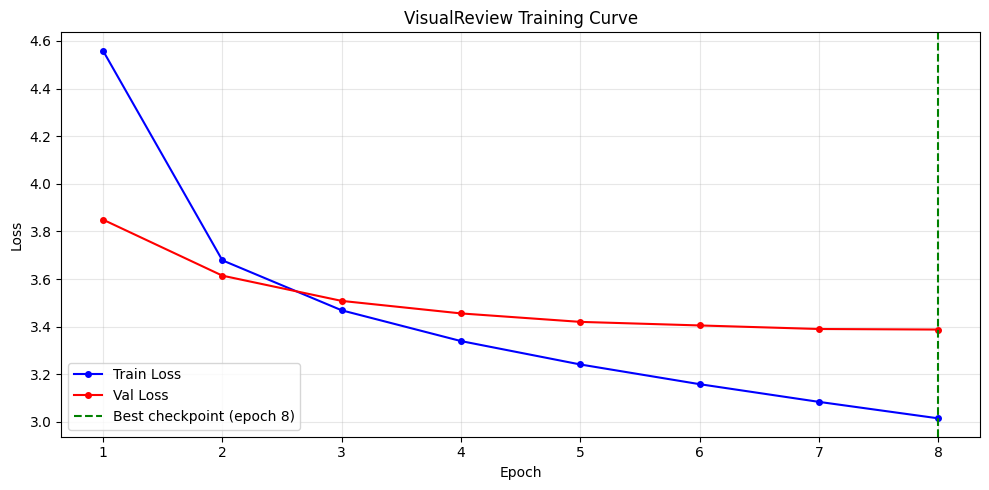

Saved to Drive as training_curve.png


In [27]:
import matplotlib.pyplot as plt

# Load loss history from the best checkpoint
train_losses = checkpoint['train_losses']
val_losses   = checkpoint['val_losses']
epochs       = list(range(1, len(train_losses) + 1))

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_losses, 'b-o', markersize=4, label='Train Loss')
plt.plot(epochs, val_losses,   'r-o', markersize=4, label='Val Loss')
plt.axvline(x=checkpoint['epoch'], color='green', linestyle='--',
            label=f"Best checkpoint (epoch {checkpoint['epoch']})")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('VisualReview Training Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{project_dir}/training_curve.png', dpi=150)
plt.show()
print("Saved to Drive as training_curve.png")

Testing the model

In [10]:
import torch
import torch.nn.functional as F
from tokenizers import Tokenizer
from torchvision import transforms
from PIL import Image
import os

# ── Load checkpoint ────────────────────────────────────────
checkpoint_path = f'{CHECKPOINT_DIR}/best_model.pt'

model_infer = VisualReviewModel(
    vocab_size = VOCAB_SIZE,
    embed_dim  = EMBED_DIM,
    num_heads  = NUM_HEADS,
    num_layers = NUM_LAYERS,
    ff_dim     = FF_DIM,
    max_length = MAX_LENGTH,
    dropout    = 0.0,   # no dropout at inference
).to(DEVICE)

checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
model_infer.load_state_dict(checkpoint['model_state'])
model_infer.eval()

print(f"✅ Loaded checkpoint")
print(f"   Saved at epoch : {checkpoint['epoch']}")
print(f"   Val loss       : {checkpoint['val_loss']:.4f}")
print(f"   Val PPL        : {checkpoint['val_ppl']:.1f}")

✅ Loaded checkpoint
   Saved at epoch : 8
   Val loss       : 3.3881
   Val PPL        : 29.6


In [11]:
# ── Tokenizer ──────────────────────────────────────────────
infer_tokenizer = Tokenizer.from_file(tokenizer_path)
bos_id = infer_tokenizer.token_to_id('[BOS]')
eos_id = infer_tokenizer.token_to_id('[EOS]')
pad_id = infer_tokenizer.token_to_id('[PAD]')

print(f"BOS id : {bos_id}")
print(f"EOS id : {eos_id}")
print(f"PAD id : {pad_id}")

# Verify control tokens are in vocab
for tok in ['[S1]','[S2]','[S3]','[S4]','[S5]',
            '[P1]','[P2]','[P3]',
            '[A1]','[A2]','[A3]','[A4]','[A5]']:
    tid = infer_tokenizer.token_to_id(tok)
    print(f"  {tok} → id {tid}")

# ── Image transform (same as training) ────────────────────
infer_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

BOS id : 2
EOS id : 3
PAD id : 1
  [S1] → id 4
  [S2] → id 5
  [S3] → id 6
  [S4] → id 7
  [S5] → id 8
  [P1] → id 9
  [P2] → id 10
  [P3] → id 11
  [A1] → id 12
  [A2] → id 13
  [A3] → id 14
  [A4] → id 15
  [A5] → id 16


In [28]:
@torch.no_grad()
@torch.no_grad()
def generate_review(image_tensor, control_prefix,
                    max_new_tokens=150,
                    temperature=0.8,
                    top_p=0.85,
                    repetition_penalty=1.3):   # ← change 1: new param
    """
    Generate one review given a preprocessed image tensor
    and a control prefix string like "[S5] [P2] [A1]".
    repetition_penalty > 1.0 discourages repeating tokens
    already in the generated output (1.3 is a good default).
    """
    encoding  = infer_tokenizer.encode(control_prefix)
    token_ids = encoding.ids
    input_ids = torch.tensor([token_ids], dtype=torch.long).to(DEVICE)

    image_features = model_infer.encoder(image_tensor)
    image_kv       = model_infer.bridge(image_features)

    generated = []

    for _ in range(max_new_tokens):
        input_ids_capped = input_ids[:, -MAX_LENGTH:]

        logits      = model_infer.decoder(input_ids_capped, image_kv)
        next_logits = logits[:, -1, :] / temperature

        # ── change 2: repetition penalty ──────────────────────
        # divide logit of every token already generated by the
        # penalty factor (>1 = lower prob, ≤ never boost)
        if generated and repetition_penalty != 1.0:
            penalty_tokens = set(generated)
            for tid in penalty_tokens:
                if next_logits[0, tid] > 0:
                    next_logits[0, tid] /= repetition_penalty
                else:
                    next_logits[0, tid] *= repetition_penalty
        # ──────────────────────────────────────────────────────

        sorted_logits, sorted_indices = torch.sort(next_logits, descending=True)
        cumulative_probs = torch.cumsum(
            F.softmax(sorted_logits, dim=-1), dim=-1
        )
        sorted_indices_to_remove = cumulative_probs - \
            F.softmax(sorted_logits, dim=-1) > top_p
        sorted_logits[sorted_indices_to_remove] = float('-inf')

        probs      = F.softmax(sorted_logits, dim=-1)
        next_token = sorted_indices[0][torch.multinomial(probs[0], 1)]
        next_token_2d = next_token.unsqueeze(0)

        if next_token.item() == eos_id:
            break

        generated.append(next_token.item())
        input_ids = torch.cat([input_ids, next_token_2d], dim=1)

    generated = [t for t in generated
                 if t not in {eos_id, pad_id, bos_id}]
    return infer_tokenizer.decode(generated)

def generate_five_reviews(asin, temperature=0.8, top_p=0.9):
    """
    Given a product ASIN, load its image and generate 5 controlled reviews.
    """
    image_path = f"{image_dir}/{asin}.jpg"

    if not os.path.exists(image_path):
        print(f"❌ Image not found: {image_path}")
        return

    img    = Image.open(image_path).convert('RGB')
    image  = infer_transform(img).unsqueeze(0).to(DEVICE)

    specs = [
        ("[S5] [P2] [A1]", "★★★★★ | Enthusiast   | Performance"),
        ("[S4] [P3] [A5]", "★★★★☆ | Casual user  | Ease of use"),
        ("[S3] [P3] [A2]", "★★★☆☆ | Casual user  | Design     "),
        ("[S2] [P1] [A4]", "★★☆☆☆ | Budget buyer | Durability "),
        ("[S1] [P1] [A3]", "★☆☆☆☆ | Budget buyer | Value      "),
    ]

    print(f"\n{'='*65}")
    print(f"  Product ASIN : {asin}")
    print(f"  Image        : {image_path}")
    print(f"{'='*65}")

    for prefix, label in specs:
        review = generate_review(image, prefix, temperature=temperature,
                                 top_p=top_p)
        print(f"\n  [{label}]")
        print(f"  {review}")
        print(f"  {'-'*60}")

In [29]:
# Verify the model is loaded and generates something non-empty
# Use the very first image in the test set
sample_asin = test_df['parent_asin'].iloc[0]
image_path  = f"{image_dir}/{sample_asin}.jpg"

img    = Image.open(image_path).convert('RGB')
image  = infer_transform(img).unsqueeze(0).to(DEVICE)

test_review = generate_review(image, "[S5] [P3] [A1]",
                               max_new_tokens=30, temperature=0.8)

print(f"Sample ASIN    : {sample_asin}")
print(f"Sample output  : {test_review}")
print(f"Token count    : {len(test_review.split())}")

assert len(test_review.strip()) > 0, "❌ Model generated empty output!"
print("\n✅ Model is generating text. Ready for full inference.")

Sample ASIN    : B07HDFV6PZ
Sample output  : . Saved a lot of $$$. This kit is for the most part .
Token count    : 14

✅ Model is generating text. Ready for full inference.


In [30]:
# Pick 3 products from the test set that have images
test_asins = []
for asin in test_df['parent_asin'].unique():
    if os.path.exists(f"{image_dir}/{asin}.jpg"):
        test_asins.append(asin)
    if len(test_asins) == 3:
        break

for asin in test_asins:
    generate_five_reviews(asin, temperature=0.8, top_p=0.9)


  Product ASIN : B07HDFV6PZ
  Image        : /home/clc3650/VisualReview/data/images/B07HDFV6PZ.jpg

  [★★★★★ | Enthusiast   | Performance]
  watched a YouTube video on how to install it . Works perfectly ! Took about 10 min total instead of you tube videos show what steps are needed
  ------------------------------------------------------------

  [★★★★☆ | Casual user  | Ease of use]
  instructions were a bit difficult to understand . Otherwise the replacement parts worked great !
  ------------------------------------------------------------

  [★★★☆☆ | Casual user  | Design     ]
  . a very poor design , not easy to replace but it is good
  ------------------------------------------------------------

  [★★☆☆☆ | Budget buyer | Durability ]
  . I ordered the same part and everything was great with installation . It lasted 3 days before it broke again ( see pic ). Not a big deal as you can feel the quality of this one is poor .
  -------------------------------------------------------

In [31]:
# You can paste any ASIN from the test set here to inspect a specific product
# Or try different temperature/top_p settings to see how generation changes

specific_asin = test_df['parent_asin'].iloc[42]  # change the index
generate_five_reviews(specific_asin, temperature=0.8, top_p=0.9)

# Try again with higher temperature for more diverse/creative output
print("\n\n--- Same product, higher temperature (more creative) ---")
generate_five_reviews(specific_asin, temperature=1.2, top_p=0.9)

# Try with lower temperature for more conservative/repetitive output
print("\n\n--- Same product, lower temperature (more conservative) ---")
generate_five_reviews(specific_asin, temperature=0.5, top_p=0.9)


  Product ASIN : B00KJ07SEM
  Image        : /home/clc3650/VisualReview/data/images/B00KJ07SEM.jpg

  [★★★★★ | Enthusiast   | Performance]
  like the taste and the filter . No chemicals or odors detected by any refrigerator
  ------------------------------------------------------------

  [★★★★☆ | Casual user  | Ease of use]
  made the install easy and as far as I can tell , it does what it is supposed to do .
  ------------------------------------------------------------

  [★★★☆☆ | Casual user  | Design     ]
  it looks like the same as my last one but the hole in the top is too small
  ------------------------------------------------------------

  [★★☆☆☆ | Budget buyer | Durability ]
  . don ' t know if it was a mistake or the water quality but I thought I would give this product a try since my original filter lasted 10 years before noticing tiny bits of charcoal in my cup , as well as charcoal dust that eventually accumulate build up over time and you have to clean out your ice a

# Code evaluation

  VisualReview — Step 12: Evaluation

Evaluating on 200 products from the test set.

Generating reviews and computing metrics …

  [25/200] products processed …
  [50/200] products processed …
  [75/200] products processed …
  [100/200] products processed …
  [125/200] products processed …
  [150/200] products processed …
  [175/200] products processed …
  [200/200] products processed …

  Done — 200 products × 5 reviews = 1000 total generated reviews.


  EVALUATION RESULTS

── 1. BLEU scores (vs held-out test reviews for same product) ──
   BLEU-1 : 0.3275
   BLEU-2 : 0.1244
   BLEU-4 : 0.0279
   Note: BLEU 2–8 is expected for open-ended review generation.

── 2. Diversity (Distinct-n across 5 reviews per product) ──────
   Distinct-1 : 0.6558  (unique unigrams / total unigrams)
   Distinct-2 : 0.9651  (unique bigrams  / total bigrams)
   Note: >0.70 distinct-2 indicates good review diversity.

── 3. Sentiment accuracy (★1/★2 = negative, ★4/★5 = positive) ─
   Overall : 77.9%
   ★1 (

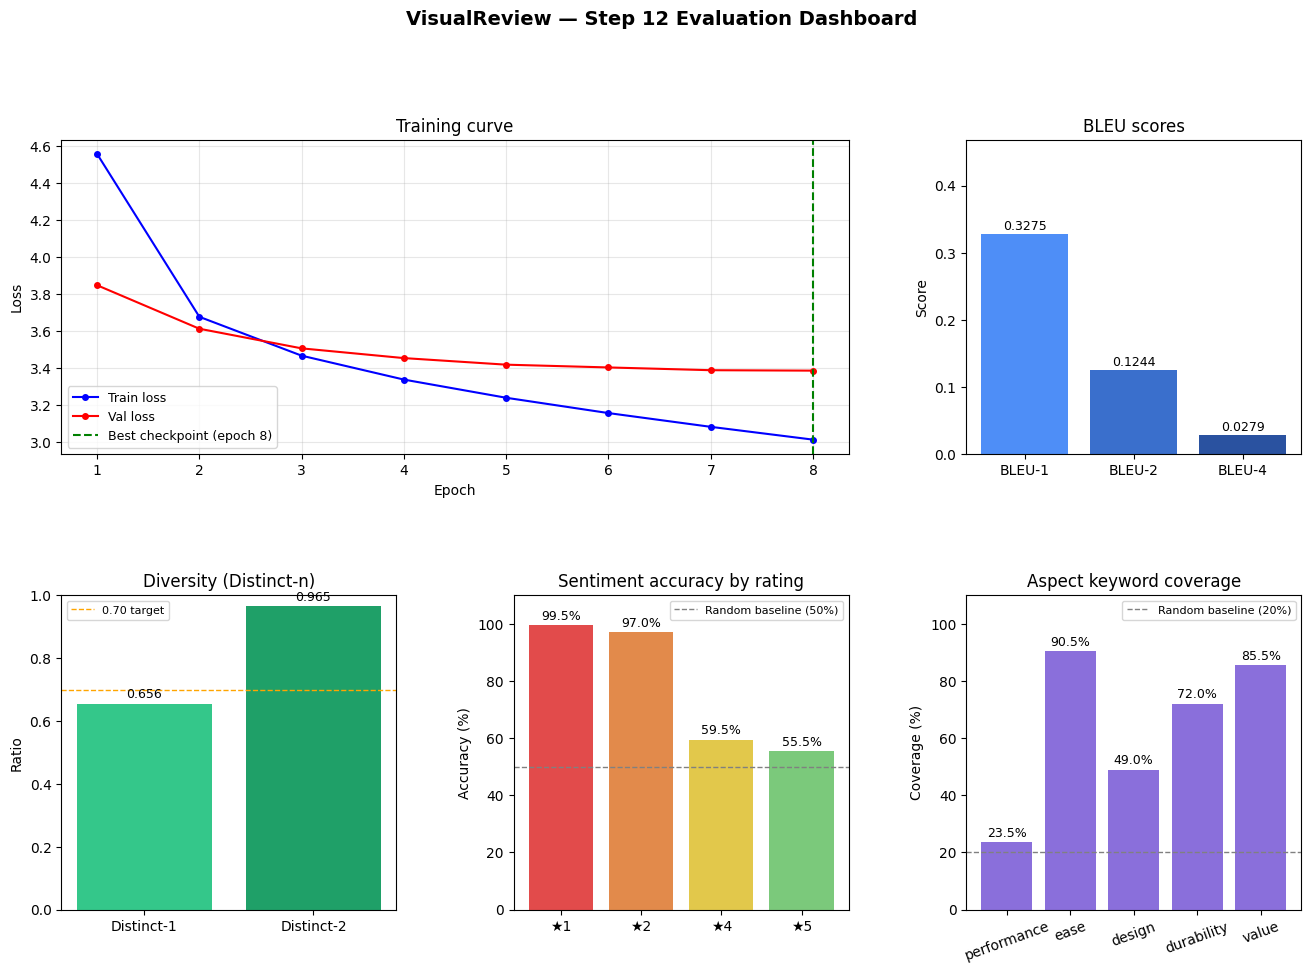

Dashboard saved to: /home/clc3650/VisualReview/eval_dashboard.png


In [34]:
"""
VisualReview — Step 12: Evaluation
====================================
Four metrics computed on the test set:
  1. BLEU-1/2/4        — n-gram overlap vs held-out references
  2. Distinct-1/2      — diversity across the 5 generated reviews per product
  3. Sentiment accuracy — does [S1] read negative, [S5] positive?
  4. Aspect coverage   — does the generated text mention the target aspect?

Run in the same Colab / Quest session where train.py was executed so that
all global config variables (VOCAB_SIZE, EMBED_DIM, …) and model classes
are already defined.  The only new dependencies are nltk and numpy (both
pre-installed on Colab / Quest).
"""

import os
import math
import json
import random
import numpy as np
from collections import Counter, defaultdict

import torch
import torch.nn.functional as F
from PIL import Image

import nltk
nltk.download('punkt',      quiet=True)
nltk.download('punkt_tab',  quiet=True)
from nltk.tokenize import word_tokenize
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# ── re-use globals already defined in the notebook ──────────────────────────
# DEVICE, VOCAB_SIZE, EMBED_DIM, NUM_HEADS, NUM_LAYERS, FF_DIM,
# MAX_LENGTH, IMAGE_SIZE, CHECKPOINT_DIR, image_dir, tokenizer_path,
# test_df, infer_tokenizer, infer_transform, model_infer,
# generate_review  (the updated version with repetition_penalty)
# ─────────────────────────────────────────────────────────────────────────────


# ════════════════════════════════════════════════════════════════════════════
# CONFIG
# ════════════════════════════════════════════════════════════════════════════

NUM_EVAL_PRODUCTS  = 200    # products sampled from test set
REVIEWS_PER_PRODUCT = 5     # one per control combo
TEMPERATURE        = 0.8
TOP_P              = 0.85
REPETITION_PENALTY = 1.3

# The 5 fixed control combos (same as inference)
CONTROL_SPECS = [
    ("[S5] [P2] [A1]", 5, "performance"),
    ("[S4] [P3] [A5]", 4, "ease"),
    ("[S3] [P3] [A2]", 3, "design"),
    ("[S2] [P1] [A4]", 2, "durability"),
    ("[S1] [P1] [A3]", 1, "value"),
]

# Keywords used to judge aspect coverage (mirrors training labeling logic)
ASPECT_KEYWORDS = {
    "performance" : ["work", "perform", "function", "fast", "speed", "power",
                     "efficient", "effective", "output", "result"],
    "design"      : ["design", "look", "style", "color", "size", "shape",
                     "appearance", "aesthetic", "build", "form"],
    "value"       : ["price", "cost", "value", "worth", "cheap", "expensive",
                     "money", "deal", "afford", "budget"],
    "durability"  : ["last", "durable", "broke", "break", "quality", "sturdy",
                     "worn", "hold", "solid", "long"],
    "ease"        : ["easy", "simple", "install", "use", "setup", "intuitive",
                     "difficult", "hard", "manual", "instruction"],
}

# Simple word lists for sentiment accuracy check
POSITIVE_WORDS = {"great", "good", "excellent", "perfect", "love", "best",
                  "amazing", "wonderful", "happy", "pleased", "fantastic",
                  "works", "recommend", "easy", "clean", "fresh"}
NEGATIVE_WORDS = {"bad", "terrible", "awful", "worst", "broke", "broken",
                  "disappointed", "waste", "useless", "poor", "cheap",
                  "not", "doesn", "didn", "never", "fail", "leak", "return"}


# ════════════════════════════════════════════════════════════════════════════
# HELPERS
# ════════════════════════════════════════════════════════════════════════════

def tokenize(text: str) -> list[str]:
    """Lowercase word-tokenize, strip punctuation tokens."""
    tokens = word_tokenize(text.lower())
    return [t for t in tokens if t.isalpha()]


def sentiment_score(text: str) -> float:
    """
    Returns a score in [-1, +1].
    Positive words contribute +1, negative words -1, normalised by length.
    Threshold: >0.0 = positive sentiment, <=0.0 = negative sentiment.
    """
    tokens = tokenize(text)
    if not tokens:
        return 0.0
    pos = sum(1 for t in tokens if t in POSITIVE_WORDS)
    neg = sum(1 for t in tokens if t in NEGATIVE_WORDS)
    return (pos - neg) / len(tokens)


def aspect_hit(text: str, aspect: str) -> bool:
    """True if any keyword for the given aspect appears in the text."""
    tokens = set(tokenize(text))
    return any(kw in tokens for kw in ASPECT_KEYWORDS[aspect])


def distinct_n(texts: list[str], n: int) -> float:
    """
    Distinct-n: ratio of unique n-grams to total n-grams across all texts.
    Measures intra-set diversity (higher = more diverse).
    """
    all_ngrams   = []
    unique_ngrams = set()
    for text in texts:
        tokens = tokenize(text)
        ngrams = list(zip(*[tokens[i:] for i in range(n)]))
        all_ngrams.extend(ngrams)
        unique_ngrams.update(ngrams)
    return len(unique_ngrams) / max(len(all_ngrams), 1)


def compute_bleu(hypothesis: str, references: list[str]) -> dict[str, float]:
    """
    Compute sentence-level BLEU-1, BLEU-2, BLEU-4 for one hypothesis
    against a list of reference strings.
    Uses NLTK's Chen & Cherry smoothing (method1) to handle short sentences.
    """
    hyp  = tokenize(hypothesis)
    refs = [tokenize(r) for r in references if r.strip()]
    if not hyp or not refs:
        return {"bleu1": 0.0, "bleu2": 0.0, "bleu4": 0.0}
    smooth = SmoothingFunction().method1
    return {
        "bleu1": sentence_bleu(refs, hyp, weights=(1,0,0,0),       smoothing_function=smooth),
        "bleu2": sentence_bleu(refs, hyp, weights=(0.5,0.5,0,0),   smoothing_function=smooth),
        "bleu4": sentence_bleu(refs, hyp, weights=(0.25,)*4,       smoothing_function=smooth),
    }


# ════════════════════════════════════════════════════════════════════════════
# STEP 1 — SAMPLE TEST PRODUCTS
# ════════════════════════════════════════════════════════════════════════════

print("=" * 65)
print("  VisualReview — Step 12: Evaluation")
print("=" * 65)

# Keep only products that have a local image file
available = [
    asin for asin in test_df["parent_asin"].unique()
    if os.path.exists(f"{image_dir}/{asin}.jpg")
]
random.seed(42)
eval_asins = random.sample(available, min(NUM_EVAL_PRODUCTS, len(available)))
print(f"\nEvaluating on {len(eval_asins)} products from the test set.")

# Build a lookup: asin → list of real review texts (all star ratings pooled)
asin_to_refs = defaultdict(list)
for _, row in test_df[test_df["parent_asin"].isin(eval_asins)].iterrows():
    asin_to_refs[row["parent_asin"]].append(str(row["text"]))


# ════════════════════════════════════════════════════════════════════════════
# STEP 2 — GENERATE REVIEWS + COLLECT METRICS
# ════════════════════════════════════════════════════════════════════════════

print("\nGenerating reviews and computing metrics …\n")

# Accumulators
bleu_scores         = {"bleu1": [], "bleu2": [], "bleu4": []}
distinct1_list      = []
distinct2_list      = []
sentiment_correct   = []    # per review
aspect_hit_list     = []    # per review
per_star_sentiment  = defaultdict(list)   # star → [correct/incorrect]
per_aspect_coverage = defaultdict(list)   # aspect → [hit/miss]

for i, asin in enumerate(eval_asins):
    if (i + 1) % 25 == 0:
        print(f"  [{i+1}/{len(eval_asins)}] products processed …")

    # Load + transform image once
    img        = Image.open(f"{image_dir}/{asin}.jpg").convert("RGB")
    image      = infer_transform(img).unsqueeze(0).to(DEVICE)
    refs       = asin_to_refs[asin]

    generated_texts = []   # collect all 5 reviews for distinct-n

    for prefix, star, aspect in CONTROL_SPECS:
        review = generate_review(
            image, prefix,
            max_new_tokens    = 150,
            temperature       = TEMPERATURE,
            top_p             = TOP_P,
            repetition_penalty= REPETITION_PENALTY,
        )

        generated_texts.append(review)

        # ── BLEU ──────────────────────────────────────────────────────────
        b = compute_bleu(review, refs)
        for k in bleu_scores:
            bleu_scores[k].append(b[k])

        # ── Sentiment accuracy ─────────────────────────────────────────────
        score  = sentiment_score(review)
        # 5/4 star → should be positive (score > 0)
        # 1/2 star → should be negative (score <= 0)
        # 3 star   → skipped (neutral, ambiguous)
        if star >= 4:
            correct = score > 0
            sentiment_correct.append(correct)
            per_star_sentiment[star].append(correct)
        elif star <= 2:
            correct = score <= 0
            sentiment_correct.append(correct)
            per_star_sentiment[star].append(correct)

        # ── Aspect coverage ───────────────────────────────────────────────
        hit = aspect_hit(review, aspect)
        aspect_hit_list.append(hit)
        per_aspect_coverage[aspect].append(hit)

    # ── Distinct-n (across the 5 reviews for this product) ────────────────
    distinct1_list.append(distinct_n(generated_texts, 1))
    distinct2_list.append(distinct_n(generated_texts, 2))

print(f"\n  Done — {len(eval_asins)} products × {REVIEWS_PER_PRODUCT} reviews "
      f"= {len(eval_asins) * REVIEWS_PER_PRODUCT} total generated reviews.")


# ════════════════════════════════════════════════════════════════════════════
# STEP 3 — AGGREGATE AND PRINT RESULTS
# ════════════════════════════════════════════════════════════════════════════

def pct(lst):
    return 100 * sum(lst) / max(len(lst), 1)

def mean(lst):
    return sum(lst) / max(len(lst), 1)

print("\n")
print("=" * 65)
print("  EVALUATION RESULTS")
print("=" * 65)

# ── BLEU ──────────────────────────────────────────────────────────────────
print("\n── 1. BLEU scores (vs held-out test reviews for same product) ──")
print(f"   BLEU-1 : {mean(bleu_scores['bleu1']):.4f}")
print(f"   BLEU-2 : {mean(bleu_scores['bleu2']):.4f}")
print(f"   BLEU-4 : {mean(bleu_scores['bleu4']):.4f}")
print("   Note: BLEU 2–8 is expected for open-ended review generation.")

# ── Distinct-n ────────────────────────────────────────────────────────────
print("\n── 2. Diversity (Distinct-n across 5 reviews per product) ──────")
print(f"   Distinct-1 : {mean(distinct1_list):.4f}  "
      f"(unique unigrams / total unigrams)")
print(f"   Distinct-2 : {mean(distinct2_list):.4f}  "
      f"(unique bigrams  / total bigrams)")
print("   Note: >0.70 distinct-2 indicates good review diversity.")

# ── Sentiment accuracy ────────────────────────────────────────────────────
print("\n── 3. Sentiment accuracy (★1/★2 = negative, ★4/★5 = positive) ─")
print(f"   Overall : {pct(sentiment_correct):.1f}%")
for star in sorted(per_star_sentiment):
    label = "positive" if star >= 4 else "negative"
    acc   = pct(per_star_sentiment[star])
    n     = len(per_star_sentiment[star])
    print(f"   ★{star} ({label:8s}) : {acc:5.1f}%  (n={n})")

# ── Aspect coverage ───────────────────────────────────────────────────────
print("\n── 4. Aspect coverage (target keyword present in review) ────────")
print(f"   Overall : {pct(aspect_hit_list):.1f}%")
aspect_order = ["performance", "ease", "design", "durability", "value"]
for asp in aspect_order:
    cov = pct(per_aspect_coverage[asp])
    n   = len(per_aspect_coverage[asp])
    print(f"   {asp:12s} : {cov:5.1f}%  (n={n})")

print("\n" + "=" * 65)


# ════════════════════════════════════════════════════════════════════════════
# STEP 4 — SAVE RESULTS TO JSON (for writeup / figures)
# ════════════════════════════════════════════════════════════════════════════

results = {
    "num_products"      : len(eval_asins),
    "reviews_evaluated" : len(eval_asins) * REVIEWS_PER_PRODUCT,
    "temperature"       : TEMPERATURE,
    "top_p"             : TOP_P,
    "repetition_penalty": REPETITION_PENALTY,
    "bleu": {
        "bleu1": round(mean(bleu_scores["bleu1"]), 4),
        "bleu2": round(mean(bleu_scores["bleu2"]), 4),
        "bleu4": round(mean(bleu_scores["bleu4"]), 4),
    },
    "diversity": {
        "distinct1": round(mean(distinct1_list), 4),
        "distinct2": round(mean(distinct2_list), 4),
    },
    "sentiment_accuracy": {
        "overall": round(pct(sentiment_correct), 2),
        "per_star": {
            str(s): round(pct(v), 2)
            for s, v in per_star_sentiment.items()
        },
    },
    "aspect_coverage": {
        "overall": round(pct(aspect_hit_list), 2),
        "per_aspect": {
            a: round(pct(per_aspect_coverage[a]), 2)
            for a in aspect_order
        },
    },
}

out_path = f"{project_dir}/eval_results.json"
with open(out_path, "w") as f:
    json.dump(results, f, indent=2)

print(f"\nResults saved to: {out_path}")


# ════════════════════════════════════════════════════════════════════════════
# STEP 5 — QUICK VISUALISATION (loss curve + eval bar charts)
# ════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── (a) Training curve ────────────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0, :2])
train_losses_plot = checkpoint["train_losses"]
val_losses_plot   = checkpoint["val_losses"]
epochs_plot       = list(range(1, len(train_losses_plot) + 1))
ax0.plot(epochs_plot, train_losses_plot, "b-o", ms=4, label="Train loss")
ax0.plot(epochs_plot, val_losses_plot,   "r-o", ms=4, label="Val loss")
ax0.axvline(x=checkpoint["epoch"], color="green", linestyle="--",
            label=f"Best checkpoint (epoch {checkpoint['epoch']})")
ax0.set_xlabel("Epoch"); ax0.set_ylabel("Loss")
ax0.set_title("Training curve", fontsize=12)
ax0.legend(fontsize=9); ax0.grid(True, alpha=0.3)

# ── (b) BLEU ──────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 2])
bleu_vals   = [results["bleu"]["bleu1"],
               results["bleu"]["bleu2"],
               results["bleu"]["bleu4"]]
bleu_labels = ["BLEU-1", "BLEU-2", "BLEU-4"]
bars = ax1.bar(bleu_labels, bleu_vals, color=["#4e8ef7","#3a6fcc","#2a52a0"])
ax1.set_ylim(0, max(bleu_vals) * 1.4 + 0.01)
ax1.set_title("BLEU scores", fontsize=12); ax1.set_ylabel("Score")
for bar, val in zip(bars, bleu_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f"{val:.4f}", ha="center", va="bottom", fontsize=9)

# ── (c) Distinct-n ────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
dist_vals   = [results["diversity"]["distinct1"],
               results["diversity"]["distinct2"]]
dist_labels = ["Distinct-1", "Distinct-2"]
bars2 = ax2.bar(dist_labels, dist_vals, color=["#34c78a","#1fa068"])
ax2.set_ylim(0, 1.0)
ax2.axhline(0.7, color="orange", linestyle="--", linewidth=1,
            label="0.70 target")
ax2.set_title("Diversity (Distinct-n)", fontsize=12)
ax2.set_ylabel("Ratio"); ax2.legend(fontsize=8)
for bar, val in zip(bars2, dist_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{val:.3f}", ha="center", va="bottom", fontsize=9)

# ── (d) Sentiment accuracy per star ───────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
stars_sorted = sorted(results["sentiment_accuracy"]["per_star"].keys())
sent_vals    = [results["sentiment_accuracy"]["per_star"][s]
                for s in stars_sorted]
colors_sent  = ["#e24b4b","#e28a4b","#e2c84b","#7bc97b"]
bars3 = ax3.bar([f"★{s}" for s in stars_sorted], sent_vals,
                color=colors_sent[:len(stars_sorted)])
ax3.set_ylim(0, 110)
ax3.axhline(50, color="gray", linestyle="--", linewidth=1,
            label="Random baseline (50%)")
ax3.set_title("Sentiment accuracy by rating", fontsize=12)
ax3.set_ylabel("Accuracy (%)"); ax3.legend(fontsize=8)
for bar, val in zip(bars3, sent_vals):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{val:.1f}%", ha="center", va="bottom", fontsize=9)

# ── (e) Aspect coverage ───────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
asp_vals = [results["aspect_coverage"]["per_aspect"][a]
            for a in aspect_order]
bars4 = ax4.bar(aspect_order, asp_vals, color="#8a6fdb")
ax4.set_ylim(0, 110)
ax4.axhline(20, color="gray", linestyle="--", linewidth=1,
            label="Random baseline (20%)")
ax4.set_title("Aspect keyword coverage", fontsize=12)
ax4.set_ylabel("Coverage (%)"); ax4.legend(fontsize=8)
ax4.tick_params(axis="x", labelrotation=20)
for bar, val in zip(bars4, asp_vals):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{val:.1f}%", ha="center", va="bottom", fontsize=9)

fig.suptitle("VisualReview — Step 12 Evaluation Dashboard", fontsize=14,
             fontweight="bold", y=1.01)

plt.savefig(f"{project_dir}/eval_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Dashboard saved to: {project_dir}/eval_dashboard.png")

# GRAD-CAM 
(helps us understand what pixel is the model refering to while generating the reviews)

In [3]:
"""
VisualReview — Step 13: Grad-CAM Explainability (Extra Credit)
================================================================
QUEST VERSION — fully self-contained, no Colab, no Drive mount.
Run from your Quest terminal:

    cd ~/VisualReview
    python step13_gradcam.py

Or submit via SLURM (see bottom of file for sbatch template).

Outputs saved to ~/VisualReview/gradcam/
"""

# ════════════════════════════════════════════════════════════════════════════
# 1. IMPORTS
# ════════════════════════════════════════════════════════════════════════════
import os, re, random
import numpy as np
import matplotlib
matplotlib.use('Agg')          # no display needed on Quest
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from tokenizers import Tokenizer
import pandas as pd

# ════════════════════════════════════════════════════════════════════════════
# 2. CONFIG & PATHS
# ════════════════════════════════════════════════════════════════════════════
project_dir    = os.path.expanduser('~/VisualReview')
image_dir      = f'{project_dir}/data/images'
tokenizer_path = f'{project_dir}/tokenizer/appliances_bpe_tokenizer.json'
processed_dir  = f'{project_dir}/processed'
CHECKPOINT_DIR = f'{project_dir}/checkpoints'
gradcam_dir    = f'{project_dir}/gradcam'
os.makedirs(gradcam_dir, exist_ok=True)

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EMBED_DIM   = 512
NUM_HEADS   = 8
NUM_LAYERS  = 6
FF_DIM      = 2048
MAX_LENGTH  = 256
VOCAB_SIZE  = 16000

NUM_GRADCAM_PRODUCTS = 5
TEMPERATURE          = 0.8
TOP_P                = 0.85
REPETITION_PENALTY   = 1.3

CONTROL_SPECS = [
    ("[S5] [P2] [A1]", "5star_enthusiast_performance"),
    ("[S4] [P3] [A5]", "4star_casual_ease"),
    ("[S3] [P3] [A2]", "3star_casual_design"),
    ("[S2] [P1] [A4]", "2star_budget_durability"),
    ("[S1] [P1] [A3]", "1star_budget_value"),
]

CONTROL_LABELS = [
    "★★★★★\nEnthusiast · Performance",
    "★★★★☆\nCasual · Ease of use",
    "★★★☆☆\nCasual · Design",
    "★★☆☆☆\nBudget · Durability",
    "★☆☆☆☆\nBudget · Value",
]

print(f"Project dir : {project_dir}")
print(f"Device      : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU         : {torch.cuda.get_device_name(0)}")
    print(f"VRAM        : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

# ════════════════════════════════════════════════════════════════════════════
# 3. MODEL CLASS DEFINITIONS (exact copies from train.py)
# ════════════════════════════════════════════════════════════════════════════

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3,
                               stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3,
                               stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)
        self.skip  = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
            nn.BatchNorm2d(out_channels)
        ) if (stride != 1 or in_channels != out_channels) else nn.Identity()

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out + self.skip(x))


class ImageEncoder(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )
        self.layer1 = self._make_layer(64,  64,  2, stride=1)
        self.layer2 = self._make_layer(64,  128, 2, stride=2)
        self.layer3 = self._make_layer(128, 256, 2, stride=2)
        self.layer4 = self._make_layer(256, 512, 2, stride=2)
        self.proj      = nn.Conv2d(512, embed_dim, kernel_size=1, bias=False)
        self.proj_norm = nn.BatchNorm2d(embed_dim)
        self._init_weights()

    def _make_layer(self, in_ch, out_ch, n_blocks, stride):
        layers = [ResidualBlock(in_ch, out_ch, stride=stride)]
        for _ in range(1, n_blocks):
            layers.append(ResidualBlock(out_ch, out_ch, stride=1))
        return nn.Sequential(*layers)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = F.relu(self.proj_norm(self.proj(x)))
        B, C, H, W = x.shape
        return x.flatten(2).permute(0, 2, 1)   # (B, 49, 512)


class CrossAttentionBridge(nn.Module):
    def __init__(self, image_dim=512, embed_dim=512):
        super().__init__()
        self.proj = nn.Linear(image_dim, embed_dim)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        return self.norm(self.proj(x))


class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim  = embed_dim // num_heads
        self.scale     = self.head_dim ** -0.5
        self.qkv       = nn.Linear(embed_dim, 3 * embed_dim)
        self.out       = nn.Linear(embed_dim, embed_dim)

    def forward(self, x, causal_mask):
        B, T, C = x.shape
        qkv = self.qkv(x).reshape(B, T, 3, self.num_heads, self.head_dim).permute(2,0,3,1,4)
        q, k, v = qkv.unbind(0)
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.masked_fill(causal_mask[:, :, :T, :T] == 0, float('-inf'))
        attn = F.softmax(attn, dim=-1)
        return self.out((attn @ v).transpose(1, 2).reshape(B, T, C))


class MultiHeadCrossAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim  = embed_dim // num_heads
        self.scale     = self.head_dim ** -0.5
        self.q_proj    = nn.Linear(embed_dim, embed_dim)
        self.kv_proj   = nn.Linear(embed_dim, 2 * embed_dim)
        self.out_proj  = nn.Linear(embed_dim, embed_dim)

    def forward(self, x, image_kv):
        B, T, C = x.shape
        _, S, _ = image_kv.shape
        q  = self.q_proj(x).reshape(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        kv = self.kv_proj(image_kv).reshape(B, S, 2, self.num_heads, self.head_dim).permute(2,0,3,1,4)
        k, v = kv.unbind(0)
        attn = F.softmax((q @ k.transpose(-2, -1)) * self.scale, dim=-1)
        return self.out_proj((attn @ v).transpose(1, 2).reshape(B, T, C))


class FeedForward(nn.Module):
    def __init__(self, embed_dim, ff_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, ff_dim), nn.GELU(), nn.Linear(ff_dim, embed_dim),
        )
    def forward(self, x): return self.net(x)


class DecoderLayer(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.ln1        = nn.LayerNorm(embed_dim)
        self.self_attn  = MultiHeadSelfAttention(embed_dim, num_heads)
        self.ln2        = nn.LayerNorm(embed_dim)
        self.cross_attn = MultiHeadCrossAttention(embed_dim, num_heads)
        self.ln3        = nn.LayerNorm(embed_dim)
        self.ff         = FeedForward(embed_dim, ff_dim)
        self.drop       = nn.Dropout(dropout)

    def forward(self, x, image_kv, causal_mask):
        x = x + self.drop(self.self_attn(self.ln1(x), causal_mask))
        x = x + self.drop(self.cross_attn(self.ln2(x), image_kv))
        x = x + self.drop(self.ff(self.ln3(x)))
        return x


class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, num_layers,
                 ff_dim, max_length, dropout=0.1):
        super().__init__()
        self.token_embed = nn.Embedding(vocab_size, embed_dim)
        self.pos_embed   = nn.Embedding(max_length, embed_dim)
        self.drop        = nn.Dropout(dropout)
        self.layers      = nn.ModuleList([
            DecoderLayer(embed_dim, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])
        self.final_ln = nn.LayerNorm(embed_dim)
        self.lm_head  = nn.Linear(embed_dim, vocab_size, bias=False)
        self.lm_head.weight = self.token_embed.weight
        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.token_embed.weight, std=0.02)
        nn.init.normal_(self.pos_embed.weight,   std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def _causal_mask(self, seq_len, device):
        return torch.tril(torch.ones(1, 1, seq_len, seq_len, device=device)).bool()

    def forward(self, input_ids, image_kv):
        B, T      = input_ids.shape
        positions = torch.arange(T, device=input_ids.device).unsqueeze(0)
        x         = self.drop(self.token_embed(input_ids) + self.pos_embed(positions))
        causal_mask = self._causal_mask(T, input_ids.device)
        for layer in self.layers:
            x = layer(x, image_kv, causal_mask)
        return self.lm_head(self.final_ln(x))


class VisualReviewModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads,
                 num_layers, ff_dim, max_length, dropout=0.1):
        super().__init__()
        self.encoder = ImageEncoder(embed_dim=embed_dim)
        self.bridge  = CrossAttentionBridge(image_dim=embed_dim, embed_dim=embed_dim)
        self.decoder = Decoder(vocab_size, embed_dim, num_heads,
                               num_layers, ff_dim, max_length, dropout)

    def forward(self, images, input_ids):
        image_features = self.encoder(images)
        image_kv       = self.bridge(image_features)
        return self.decoder(input_ids, image_kv)


print("✅ All model classes defined.")

# ════════════════════════════════════════════════════════════════════════════
# 4. LOAD DATA, TOKENIZER, CHECKPOINT
# ════════════════════════════════════════════════════════════════════════════

test_df = pd.read_json(f'{processed_dir}/test.jsonl', lines=True)
test_df['text'] = test_df['text'].apply(lambda x: re.sub(r'<.*?>', ' ', str(x)))
print(f"Test set loaded : {len(test_df):,} reviews")

infer_tokenizer = Tokenizer.from_file(tokenizer_path)
eos_id = infer_tokenizer.token_to_id('[EOS]')
pad_id = infer_tokenizer.token_to_id('[PAD]')
bos_id = infer_tokenizer.token_to_id('[BOS]')
print(f"Tokenizer loaded. EOS={eos_id}  PAD={pad_id}  BOS={bos_id}")

infer_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

model_infer = VisualReviewModel(
    vocab_size = VOCAB_SIZE,
    embed_dim  = EMBED_DIM,
    num_heads  = NUM_HEADS,
    num_layers = NUM_LAYERS,
    ff_dim     = FF_DIM,
    max_length = MAX_LENGTH,
    dropout    = 0.0,
).to(DEVICE)

checkpoint = torch.load(f'{CHECKPOINT_DIR}/best_model.pt', map_location=DEVICE)
model_infer.load_state_dict(checkpoint['model_state'])
model_infer.eval()
print(f"✅ Checkpoint loaded — epoch {checkpoint['epoch']}, "
      f"val_loss {checkpoint['val_loss']:.4f}, "
      f"val_ppl {checkpoint['val_ppl']:.1f}")

# ════════════════════════════════════════════════════════════════════════════
# 5. GENERATE REVIEW (with repetition penalty)
# ════════════════════════════════════════════════════════════════════════════

@torch.no_grad()
def generate_review(image_tensor, control_prefix,
                    max_new_tokens=150,
                    temperature=0.8,
                    top_p=0.85,
                    repetition_penalty=1.3):
    encoding  = infer_tokenizer.encode(control_prefix)
    input_ids = torch.tensor([encoding.ids], dtype=torch.long).to(DEVICE)

    image_features = model_infer.encoder(image_tensor)
    image_kv       = model_infer.bridge(image_features)
    generated      = []

    for _ in range(max_new_tokens):
        logits      = model_infer.decoder(input_ids[:, -MAX_LENGTH:], image_kv)
        next_logits = logits[:, -1, :] / temperature

        if generated and repetition_penalty != 1.0:
            for tid in set(generated):
                if next_logits[0, tid] > 0:
                    next_logits[0, tid] /= repetition_penalty
                else:
                    next_logits[0, tid] *= repetition_penalty

        sorted_logits, sorted_indices = torch.sort(next_logits, descending=True)
        cumulative_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)
        sorted_logits[cumulative_probs - F.softmax(sorted_logits, dim=-1) > top_p] = float('-inf')

        probs         = F.softmax(sorted_logits, dim=-1)
        next_token    = sorted_indices[0][torch.multinomial(probs[0], 1)]
        next_token_2d = next_token.unsqueeze(0)

        if next_token.item() == eos_id:
            break

        generated.append(next_token.item())
        input_ids = torch.cat([input_ids, next_token_2d], dim=1)

    generated = [t for t in generated if t not in {eos_id, pad_id, bos_id}]
    return infer_tokenizer.decode(generated)

# ════════════════════════════════════════════════════════════════════════════
# 6. GRAD-CAM ENGINE
# ════════════════════════════════════════════════════════════════════════════

class GradCAM:
    """
    Hooks into encoder.layer4[-1].conv2 of the from-scratch ImageEncoder.
    Output shape: (B, 512, 7, 7) — the 49 spatial tokens fed to the decoder.
    Differentiates the top-1 logit of the first generated token.
    """

    def __init__(self, model):
        self.model       = model
        self.gradients   = None
        self.activations = None
        self.target_layer = model.encoder.layer4[-1].conv2

        self._fwd_hook = self.target_layer.register_forward_hook(self._save_activation)
        self._bwd_hook = self.target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def remove(self):
        self._fwd_hook.remove()
        self._bwd_hook.remove()

    def compute(self, image_tensor, control_prefix):
        self.model.eval()
        self.model.zero_grad()

        enc       = infer_tokenizer.encode(control_prefix)
        input_ids = torch.tensor([enc.ids], dtype=torch.long).to(DEVICE)

        with torch.enable_grad():
            image_features = self.model.encoder(image_tensor)
            image_kv       = self.model.bridge(image_features)
            logits         = self.model.decoder(input_ids, image_kv)
            next_logits    = logits[0, -1, :]
            next_logits.max().backward()

        grads   = self.gradients[0]              # (512, 7, 7)
        acts    = self.activations[0]            # (512, 7, 7)
        weights = grads.mean(dim=(1, 2))         # (512,)
        cam     = F.relu((weights[:, None, None] * acts).sum(dim=0))  # (7, 7)

        cam_min, cam_max = cam.min(), cam.max()
        cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)

        cam_224 = F.interpolate(
            cam.unsqueeze(0).unsqueeze(0),
            size=(224, 224), mode='bilinear', align_corners=False,
        ).squeeze().cpu().numpy()

        first_word = infer_tokenizer.decode([next_logits.argmax().item()]).strip()
        self.model.zero_grad()
        return cam_224, first_word


# ════════════════════════════════════════════════════════════════════════════
# 7. OVERLAY HELPER
# ════════════════════════════════════════════════════════════════════════════

def overlay_heatmap(original_pil, cam, alpha=0.45):
    orig    = np.array(original_pil.resize((224, 224))).astype(np.float32) / 255.0
    heatmap = cm.get_cmap('jet')(cam)[..., :3]
    blended = np.clip((1 - alpha) * orig + alpha * heatmap, 0, 1)
    return Image.fromarray((blended * 255).astype(np.uint8))


# ════════════════════════════════════════════════════════════════════════════
# 8. MAIN LOOP — per-product Grad-CAM figures
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 65)
print("  VisualReview — Step 13: Grad-CAM Explainability")
print("=" * 65)

random.seed(99)
available     = [a for a in test_df['parent_asin'].unique()
                 if os.path.exists(f'{image_dir}/{a}.jpg')]
gradcam_asins = random.sample(available, min(NUM_GRADCAM_PRODUCTS, len(available)))
print(f"\nSelected products: {gradcam_asins}\n")

gradcam       = GradCAM(model_infer)
border_colors = ['#4ecc6e', '#a3cc4e', '#ccb84e', '#cc784e', '#cc4e4e']

for asin in gradcam_asins:
    print(f"Processing {asin} …")

    orig_pil     = Image.open(f'{image_dir}/{asin}.jpg').convert('RGB')
    image_tensor = infer_transform(orig_pil).unsqueeze(0).to(DEVICE)

    cams, overlays, reviews, first_words = [], [], [], []

    for (prefix, slug), label in zip(CONTROL_SPECS, CONTROL_LABELS):
        cam, first_word = gradcam.compute(image_tensor, prefix)
        overlay         = overlay_heatmap(orig_pil, cam)

        with torch.no_grad():
            review = generate_review(image_tensor, prefix,
                                     max_new_tokens=100,
                                     temperature=TEMPERATURE,
                                     top_p=TOP_P,
                                     repetition_penalty=REPETITION_PENALTY)

        cams.append(cam)
        overlays.append(overlay)
        reviews.append(review)
        first_words.append(first_word)
        print(f"  {slug:35s}  first token: '{first_word}'")

    # ── Figure ───────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(22, 10))
    fig.patch.set_facecolor('#0f0f0f')
    fig.suptitle(f'Grad-CAM Explainability  ·  ASIN: {asin}',
                 fontsize=14, fontweight='bold', color='white', y=0.98)

    gs_top = fig.add_gridspec(1, 6, left=0.02, right=0.98,
                               top=0.88, bottom=0.42, wspace=0.04)
    ax_orig = fig.add_subplot(gs_top[0])
    ax_orig.imshow(orig_pil.resize((224, 224)))
    ax_orig.set_title('Original', color='white', fontsize=10, pad=6)
    ax_orig.axis('off')

    for j, (overlay, label) in enumerate(zip(overlays, CONTROL_LABELS)):
        ax = fig.add_subplot(gs_top[j + 1])
        ax.imshow(overlay)
        ax.set_title(label, color='white', fontsize=8.5, pad=6, linespacing=1.4)
        ax.axis('off')
        for spine in ax.spines.values():
            spine.set_edgecolor(border_colors[j])
            spine.set_linewidth(2)
            spine.set_visible(True)

    gs_cbar = fig.add_gridspec(1, 1, left=0.02, right=0.12,
                                top=0.36, bottom=0.30)
    ax_cbar = fig.add_subplot(gs_cbar[0])
    ax_cbar.imshow(np.linspace(0, 1, 256).reshape(1, -1), aspect='auto', cmap='jet')
    ax_cbar.set_yticks([])
    ax_cbar.set_xticks([0, 255])
    ax_cbar.set_xticklabels(['Low', 'High'], color='white', fontsize=8)
    ax_cbar.set_title('Attention', color='white', fontsize=8, pad=3)
    for spine in ax_cbar.spines.values():
        spine.set_edgecolor('#555')

    gs_text = fig.add_gridspec(1, 5, left=0.02, right=0.98,
                                top=0.35, bottom=0.02, wspace=0.06)
    for j, (review, label) in enumerate(zip(reviews, CONTROL_LABELS)):
        ax_t = fig.add_subplot(gs_text[j])
        ax_t.set_facecolor('#1a1a1a')
        ax_t.axis('off')
        display_text = review[:220] + ('…' if len(review) > 220 else '')
        ax_t.text(0.5, 0.95, label, transform=ax_t.transAxes, fontsize=8.5,
                  color=border_colors[j], fontweight='bold',
                  ha='center', va='top', linespacing=1.5)
        ax_t.text(0.5, 0.72, f'First token: "{first_words[j]}"',
                  transform=ax_t.transAxes, fontsize=7.5,
                  color='#aaaaaa', ha='center', va='top', style='italic')
        ax_t.text(0.05, 0.60, display_text, transform=ax_t.transAxes,
                  fontsize=7.5, color='#dddddd', ha='left', va='top',
                  multialignment='left', linespacing=1.5)
        for spine in ax_t.spines.values():
            spine.set_edgecolor(border_colors[j])
            spine.set_linewidth(1.2)
            spine.set_visible(True)

    out_path = f'{gradcam_dir}/gradcam_{asin}.png'
    plt.savefig(out_path, dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.close(fig)
    print(f"  Saved → {out_path}\n")

gradcam.remove()
print(f"✅ Per-product figures done. {len(gradcam_asins)} PNGs in {gradcam_dir}/")


# ════════════════════════════════════════════════════════════════════════════
# 9. BONUS: AGGREGATE SPATIAL BIAS — positive vs negative sentiment
# ════════════════════════════════════════════════════════════════════════════

print("\n── Bonus: Aggregate spatial attention by sentiment ─────────────")

gradcam2 = GradCAM(model_infer)
pos_maps, neg_maps = [], []

for asin in gradcam_asins:
    orig_pil     = Image.open(f'{image_dir}/{asin}.jpg').convert('RGB')
    image_tensor = infer_transform(orig_pil).unsqueeze(0).to(DEVICE)

    for i, (prefix, _) in enumerate(CONTROL_SPECS):
        cam, _ = gradcam2.compute(image_tensor, prefix)
        cam_small = F.interpolate(
            torch.tensor(cam).unsqueeze(0).unsqueeze(0).float(),
            size=(7, 7), mode='bilinear', align_corners=False
        ).squeeze().numpy()

        if i < 2:     # ★5 and ★4
            pos_maps.append(cam_small)
        elif i >= 3:  # ★2 and ★1
            neg_maps.append(cam_small)

gradcam2.remove()

avg_pos = np.mean(pos_maps, axis=0)
avg_neg = np.mean(neg_maps, axis=0)
diff    = avg_pos - avg_neg

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.patch.set_facecolor('#0f0f0f')
fig.suptitle('Aggregate Spatial Attention: Positive vs Negative Reviews',
             color='white', fontsize=12, fontweight='bold')

for ax, d, title, cmap_name in zip(
    axes,
    [avg_pos, avg_neg, diff],
    ['Avg attention\n(★4+★5 reviews)',
     'Avg attention\n(★1+★2 reviews)',
     'Difference\n(positive − negative)'],
    ['YlOrRd', 'YlOrRd', 'RdBu_r']
):
    im = ax.imshow(d, cmap=cmap_name, interpolation='nearest')
    ax.set_title(title, color='white', fontsize=10, pad=6)
    ax.set_xticks(range(7))
    ax.set_yticks(range(7))
    ax.tick_params(colors='gray', labelsize=7)
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.ax.yaxis.set_tick_params(color='white', labelcolor='white')

plt.tight_layout()
agg_path = f'{gradcam_dir}/gradcam_aggregate.png'
plt.savefig(agg_path, dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.close(fig)
print(f"Aggregate map saved → {agg_path}")
print("\n✅ Step 13 complete.")
print(f"\nAll outputs in: {gradcam_dir}/")
print("Sync back to Drive with:")
print(f"  ~/bin/rclone copy {gradcam_dir}/ gdrive:VisualReview/gradcam/ --progress")

Project dir : /home/clc3650/VisualReview
Device      : cuda
GPU         : NVIDIA H100 80GB HBM3
VRAM        : 85.0 GB
✅ All model classes defined.
Test set loaded : 29,539 reviews
Tokenizer loaded. EOS=3  PAD=1  BOS=2
✅ Checkpoint loaded — epoch 8, val_loss 3.3881, val_ppl 29.6

  VisualReview — Step 13: Grad-CAM Explainability

Selected products: ['B00TL9SGIO', 'B07QYC2MPW', 'B0C7LWV6CG', 'B0BM8PBK3D', 'B08CKTXTL1']

Processing B00TL9SGIO …


/tmp/ipykernel_3099161/1498357277.py:426: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  heatmap = cm.get_cmap('jet')(cam)[..., :3]


  5star_enthusiast_performance         first token: 'the'
  4star_casual_ease                    first token: '.'
  3star_casual_design                  first token: 'the'
  2star_budget_durability              first token: '.'
  1star_budget_value                   first token: '.'
  Saved → /home/clc3650/VisualReview/gradcam/gradcam_B00TL9SGIO.png

Processing B07QYC2MPW …
  5star_enthusiast_performance         first token: 'the'
  4star_casual_ease                    first token: 'easy'


/tmp/ipykernel_3099161/1498357277.py:426: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  heatmap = cm.get_cmap('jet')(cam)[..., :3]


  3star_casual_design                  first token: 'it'
  2star_budget_durability              first token: '.'
  1star_budget_value                   first token: '.'
  Saved → /home/clc3650/VisualReview/gradcam/gradcam_B07QYC2MPW.png

Processing B0C7LWV6CG …
  5star_enthusiast_performance         first token: 'the'
  4star_casual_ease                    first token: 'it'


...

  3star_casual_design                  first token: 'it'
  2star_budget_durability              first token: '.'
  1star_budget_value                   first token: '.'
  Saved → /home/clc3650/VisualReview/gradcam/gradcam_B0C7LWV6CG.png

Processing B0BM8PBK3D …
  5star_enthusiast_performance         first token: 'I'


/tmp/ipykernel_3099161/1498357277.py:426: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  heatmap = cm.get_cmap('jet')(cam)[..., :3]


  4star_casual_ease                    first token: 'easy'
  3star_casual_design                  first token: '.'
  2star_budget_durability              first token: '.'
  1star_budget_value                   first token: 'not'
  Saved → /home/clc3650/VisualReview/gradcam/gradcam_B0BM8PBK3D.png

Processing B08CKTXTL1 …
  5star_enthusiast_performance         first token: 'the'
  4star_casual_ease                    first token: 'it'


/tmp/ipykernel_3099161/1498357277.py:426: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  heatmap = cm.get_cmap('jet')(cam)[..., :3]


  3star_casual_design                  first token: '.'
  2star_budget_durability              first token: '.'
  1star_budget_value                   first token: '.'
  Saved → /home/clc3650/VisualReview/gradcam/gradcam_B08CKTXTL1.png

✅ Per-product figures done. 5 PNGs in /home/clc3650/VisualReview/gradcam/

── Bonus: Aggregate spatial attention by sentiment ─────────────
Aggregate map saved → /home/clc3650/VisualReview/gradcam/gradcam_aggregate.png

✅ Step 13 complete.

All outputs in: /home/clc3650/VisualReview/gradcam/
Sync back to Drive with:
  ~/bin/rclone copy /home/clc3650/VisualReview/gradcam/ gdrive:VisualReview/gradcam/ --progress
